Esse notebook tem o objetivo de fazer uma análise dos dados de Hanseníase do SINAN para, posteriormente, treinar um modelo de Random Forest para definição de pesos para vulnerabilidade.

In [1]:
from pathlib import Path

from dbfread import DBF
from pyreaddbc.readdbc import dbc2dbf
import pandas as pd

pasta = Path.cwd()
dados_por_arquivo = {}

for arquivo_dbc in sorted(pasta.glob("HANSBR*.dbc")):
    arquivo_dbf = arquivo_dbc.with_suffix(".dbf")
    dbc2dbf(str(arquivo_dbc), str(arquivo_dbf))
    dados = pd.DataFrame(iter(DBF(str(arquivo_dbf), load=True)))
    dados["ARQUIVO_ORIGEM"] = arquivo_dbc.name
    dados_por_arquivo[arquivo_dbc.stem] = dados

df = pd.concat(dados_por_arquivo.values(), ignore_index=True)
df.to_csv("HANSBR_todos.csv", index=False, encoding="utf-8-sig")
df.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_DIAG,SEM_DIAG,...,ESQ_ATU_N,DOSE_RECEB,EPIS_RACIO,DTMUDESQ,CONTEXAM,DTALTA_N,TPALTA_N,IN_VINCULA,NU_LOTE_IA,ARQUIVO_ORIGEM
0,2,A309,2016-01-01,2016,21,211120,1430,2458586,2015-05-05,,...,2,NaN,1,None,1.0,2017-01-31,1,,0000000,HANSBR16.dbc
1,2,A309,2016-01-01,2016,23,230440,1519,2482088,2016-01-01,,...,2,12.0,4,None,0.0,2017-02-21,1,,0000000,HANSBR16.dbc
2,2,A309,2016-01-01,2016,43,430040,1599,6333753,2016-01-01,,...,3,1.0,4,None,1.0,2016-02-01,8,,0000000,HANSBR16.dbc
3,2,A309,2016-01-01,2016,23,231400,1530,2562758,2016-01-01,,...,1,NaN,,None,NaN,None,,,0000000,HANSBR16.dbc
4,2,A309,2016-01-03,2016,52,521523,1782,2383926,2015-11-26,,...,2,12.0,4,None,4.0,2016-12-21,1,,0000000,HANSBR16.dbc


Origem dos dados:
https://datasus.saude.gov.br/transferencia-de-arquivos/

SINAN -> DADOS -> HANS -> 2026

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316419 entries, 0 to 316418
Data columns (total 64 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TP_NOT          316419 non-null  object 
 1   ID_AGRAVO       316419 non-null  object 
 2   DT_NOTIFIC      316419 non-null  object 
 3   NU_ANO          316419 non-null  object 
 4   SG_UF_NOT       316419 non-null  object 
 5   ID_MUNICIP      316419 non-null  object 
 6   ID_REGIONA      316419 non-null  object 
 7   ID_UNIDADE      316419 non-null  object 
 8   DT_DIAG         316419 non-null  object 
 9   SEM_DIAG        316419 non-null  object 
 10  ANO_NASC        316419 non-null  object 
 11  NU_IDADE_N      316419 non-null  int64  
 12  CS_SEXO         316419 non-null  object 
 13  CS_GESTANT      316419 non-null  object 
 14  CS_RACA         316419 non-null  object 
 15  CS_ESCOL_N      316419 non-null  object 
 16  SG_UF           316419 non-null  object 
 17  ID_MN_RESI

## **1º Etapa**: Análise exploratória da base de dados

Uma olhada em como os dados do SINAN estão estruturados.

In [3]:
df.sample(10)

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_DIAG,SEM_DIAG,...,ESQ_ATU_N,DOSE_RECEB,EPIS_RACIO,DTMUDESQ,CONTEXAM,DTALTA_N,TPALTA_N,IN_VINCULA,NU_LOTE_IA,ARQUIVO_ORIGEM
24678,2,A309,2016-09-29,2016,23,230440,1519,2561492,2016-09-29,,...,2,0.0,4,None,0.0,2017-08-17,4,,0000000,HANSBR16.dbc
120757,2,A309,2019-06-12,2019,21,210160,1445,2462575,2017-06-12,,...,2,12.0,,None,0.0,2020-03-23,1,,0000000,HANSBR19.dbc
93833,2,A309,2018-09-18,2018,17,170550,,2370468,2018-09-18,,...,2,12.0,4,None,25.0,2019-11-28,1,,0000000,HANSBR18.dbc
209587,2,A309,2022-10-10,2022,51,510140,1582,2604191,2022-10-10,,...,2,6.0,4,None,2.0,2023-04-20,1,,0000000,HANSBR22.dbc
99244,2,A309,2018-11-07,2018,51,510325,1582,8013519,2018-11-07,,...,2,12.0,4,None,3.0,2019-09-19,1,,0000000,HANSBR18.dbc
213484,2,A309,2022-12-06,2022,26,260680,1497,2674092,2022-12-06,,...,2,8.0,,None,0.0,2023-12-07,2,,0000000,HANSBR22.dbc
20081,2,A309,2016-08-12,2016,52,520870,1779,2626691,2016-08-12,,...,2,1.0,4,None,0.0,2016-08-12,4,,0000000,HANSBR16.dbc
8228,2,A309,2016-04-06,2016,22,220770,1868,3511138,2016-04-01,,...,2,12.0,4,None,9.0,2017-03-30,1,,0000000,HANSBR16.dbc
41026,2,A309,2017-04-04,2017,21,210910,1443,2455137,2017-04-04,,...,1,6.0,4,None,3.0,2017-10-03,1,,0000000,HANSBR17.dbc
51154,2,A309,2017-07-19,2017,28,280170,2057,2420996,2017-07-18,,...,1,6.0,4,None,2.0,2018-02-08,1,,0000000,HANSBR17.dbc


In [4]:
display(df.shape)
display(df.info())
display(df.columns)
display(df.dtypes.value_counts())

(316419, 64)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316419 entries, 0 to 316418
Data columns (total 64 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TP_NOT          316419 non-null  object 
 1   ID_AGRAVO       316419 non-null  object 
 2   DT_NOTIFIC      316419 non-null  object 
 3   NU_ANO          316419 non-null  object 
 4   SG_UF_NOT       316419 non-null  object 
 5   ID_MUNICIP      316419 non-null  object 
 6   ID_REGIONA      316419 non-null  object 
 7   ID_UNIDADE      316419 non-null  object 
 8   DT_DIAG         316419 non-null  object 
 9   SEM_DIAG        316419 non-null  object 
 10  ANO_NASC        316419 non-null  object 
 11  NU_IDADE_N      316419 non-null  int64  
 12  CS_SEXO         316419 non-null  object 
 13  CS_GESTANT      316419 non-null  object 
 14  CS_RACA         316419 non-null  object 
 15  CS_ESCOL_N      316419 non-null  object 
 16  SG_UF           316419 non-null  object 
 17  ID_MN_RESI

None

Index(['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'DT_DIAG', 'SEM_DIAG',
       'ANO_NASC', 'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA',
       'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS',
       'NDUPLIC_N', 'DT_DIGITA', 'DT_TRANSUS', 'DT_TRANSDM', 'DT_TRANSSM',
       'DT_TRANSRM', 'DT_TRANSRS', 'DT_TRANSSE', 'NU_LOTE_V', 'NU_LOTE_H',
       'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W', 'ID_OCUPA_N', 'NU_LESOES',
       'FORMACLINI', 'AVALIA_N', 'CLASSOPERA', 'MODOENTR', 'MODODETECT',
       'BACILOSCOP', 'DTINICTRAT', 'ESQ_INI_N', 'CONTREG', 'NERVOSAFET',
       'UFATUAL', 'ID_MUNI_AT', 'DT_NOTI_AT', 'ID_UNID_AT', 'UFRESAT',
       'MUNIRESAT', 'DTULTCOMP', 'CLASSATUAL', 'AVAL_ATU_N', 'ESQ_ATU_N',
       'DOSE_RECEB', 'EPIS_RACIO', 'DTMUDESQ', 'CONTEXAM', 'DTALTA_N',
       'TPALTA_N', 'IN_VINCULA', 'NU_LOTE_IA', 'ARQUIVO_ORIGEM'],
      dtype='object')

object     58
float64     5
int64       1
Name: count, dtype: int64

Análise das colunas com valores numéricos

In [5]:
display(df.describe())

,NU_IDADE_N,NU_LESOES,CONTREG,NERVOSAFET,DOSE_RECEB,CONTEXAM
count,316419.000000,299192.000000,307425.00000,287421.000000,295458.000000,278291.000000
mean,4046.910739,7.350103,2.93346,1.967087,9.198340,2.463522
std,23.579492,11.086121,3.09186,2.844577,4.958893,2.993911
min,38.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,4034.000000,1.000000,1.00000,0.000000,6.000000,1.000000
50%,4048.000000,5.000000,2.00000,1.000000,12.000000,2.000000
75%,4060.000000,10.000000,4.00000,3.000000,12.000000,3.000000
max,4118.000000,99.000000,99.00000,99.000000,99.000000,99.000000


In [6]:
df[["NU_IDADE_N", "NU_LESOES", "CONTREG", "NERVOSAFET", "DOSE_RECEB", "CONTEXAM"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316419 entries, 0 to 316418
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   NU_IDADE_N  316419 non-null  int64  
 1   NU_LESOES   299192 non-null  float64
 2   CONTREG     307425 non-null  float64
 3   NERVOSAFET  287421 non-null  float64
 4   DOSE_RECEB  295458 non-null  float64
 5   CONTEXAM    278291 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 14.5 MB


Análise da coluna **AVALIA_N**, que é particularmente relevante para a pesquisa, pois indica o Grau de Incapacidade Física do registro.

In [7]:
display(df["AVALIA_N"].sample(20))
display(df["AVALIA_N"].value_counts(dropna=False))
display(df["AVALIA_N"].value_counts(normalize=True, dropna=False))
display(df["AVALIA_N"].unique())

27240     1
54752     0
27536     0
152371    3
99855     0
43256     1
95283     0
81883     3
108708    0
138512    0
303553    0
185849    0
210827    0
58770     0
305488    0
164398    0
121210    0
220739    3
24900     1
282875    0
Name: AVALIA_N, dtype: object

AVALIA_N
0    155747
1     90350
2     32541
3     26035
      11746
Name: count, dtype: int64

AVALIA_N
0    0.492218
1    0.285539
2    0.102841
3    0.082280
     0.037122
Name: proportion, dtype: float64

array(['1', '0', '2', '3', ''], dtype=object)

## **2º Etapa**: Tratamento.

Tratando de valores nulos nas colunas relevantes para o treinamento dos modelos

In [8]:
import numpy as np

df_tratado = df.copy() #Criando uma cópia do dataframe original para tratamento.
display(df_tratado.shape)

(316419, 64)

In [9]:
df_tratado["AVALIA_N"] = df_tratado["AVALIA_N"].replace(r"^\s*$", np.nan, regex=True)
df_tratado["AVALIA_N"].value_counts(dropna=False)

AVALIA_N
0      155747
1       90350
2       32541
3       26035
NaN     11746
Name: count, dtype: int64

In [10]:
df_tratado = df_tratado[df_tratado["AVALIA_N"].isin(["0", "1", "2"])].copy()
display(df_tratado.shape)
display(df_tratado["AVALIA_N"].value_counts(dropna=False))

(278638, 64)

AVALIA_N
0    155747
1     90350
2     32541
Name: count, dtype: int64

Adicionando a coluna **Target** que indica a classificação do Grau de Incapacidade Física (GIF) que está sendo classificada inicialmente na coluna AVALIA_N

In [11]:
df_tratado["TARGET"] = df_tratado["AVALIA_N"].map({"0": 0, "1": 1, "2": 1})
display(df_tratado["TARGET"].value_counts(dropna=False))

TARGET
0    155747
1    122891
Name: count, dtype: int64

In [12]:
pd.crosstab(df_tratado["AVALIA_N"], df_tratado["TARGET"])

TARGET,0,1
AVALIA_N,,
0,155747,0
1,0,90350
2,0,32541


**Definição de features e target**

Y/Target = porcentagem de incapacidade (Classificação probabilística):
```
AVALIA_N (no diagnostico)
```

X/Features:
```
NU_IDADE_N        → idade
CS_SEXO           → sexo
CS_RACA           → raça
CS_ESCOL_N        → escolaridade
NU_LESOES         → número de lesões
NERVOSAFET        → nervos afetados
CLASSOPERA        → PB ou MB
FORMACLINI        → forma clínica
```

Remover Features:
```
AVALIA_N / AVAL_ATU_N  X (é o target)
DTALTA_N               X (futuro)
CLASSATUAL             X (pós evolução)
DOSE_RECEB             X (tratamento)
```

Exemplo concreto de entrada

```
idade = 45
sexo = F
raca = Parda
escolaridade = Fundamental
lesoes = 6
nervos = 2
classificacao = MB
forma = Dimorfa
```

**Criação do dataframe de ML**

In [13]:
features = [
    "NU_IDADE_N",
    "CS_SEXO",
    "CS_RACA",
    "CS_ESCOL_N",
    "NU_LESOES",
    "NERVOSAFET",
    "CLASSOPERA",
    "FORMACLINI",
    "ID_OCUPA_N",
    "MODOENTR",
    "MODODETECT",
    "BACILOSCOP"
    ]

df_ml = df_tratado[features + ["TARGET"]].copy()

In [14]:
display(df_ml.shape)

(278638, 13)

In [15]:
# Tratamento de NU_IDADE_N seguindo a lógica aplicada do SINAN
'''
1o dígito define se é:
1. Hora
2. Dia
3. Mês
4. Ano
 '''

def parse_idade(x):
    if pd.isna(x):
        return None

    x = int(x)
    tipo = int(str(x)[0])
    valor = int(str(x)[1:])

    if tipo == 4:  # anos
        return valor
    elif tipo == 3:  # meses
        return valor / 12
    elif tipo == 2:  # dias
        return valor / 365
    elif tipo == 1:  # horas
        return valor / (365 * 24)
    else:
        return None

df_ml["NU_IDADE_N"] = df_ml["NU_IDADE_N"].apply(parse_idade)

In [16]:
display(df_ml["NU_IDADE_N"].describe())
display(df_ml["NU_IDADE_N"].isna().sum())
display((df_ml["NU_IDADE_N"] == 0).sum())

count    278638.000000
mean         46.833007
std          18.158320
min           0.000000
25%          34.000000
50%          48.000000
75%          60.000000
max         118.000000
Name: NU_IDADE_N, dtype: float64

np.int64(0)

np.int64(2)

Valores convertidos e sem apresentar outliers muito distantes da curva.

In [17]:
display(features)
display(df_ml[features].info())
display(df_ml[features].isna().sum()) 


['NU_IDADE_N',
 'CS_SEXO',
 'CS_RACA',
 'CS_ESCOL_N',
 'NU_LESOES',
 'NERVOSAFET',
 'CLASSOPERA',
 'FORMACLINI',
 'ID_OCUPA_N',
 'MODOENTR',
 'MODODETECT',
 'BACILOSCOP']

<class 'pandas.core.frame.DataFrame'>
Index: 278638 entries, 0 to 316418
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   NU_IDADE_N  278638 non-null  float64
 1   CS_SEXO     278638 non-null  object 
 2   CS_RACA     278638 non-null  object 
 3   CS_ESCOL_N  278638 non-null  object 
 4   NU_LESOES   267361 non-null  float64
 5   NERVOSAFET  262359 non-null  float64
 6   CLASSOPERA  278638 non-null  object 
 7   FORMACLINI  278638 non-null  object 
 8   ID_OCUPA_N  278638 non-null  object 
 9   MODOENTR    278638 non-null  object 
 10  MODODETECT  278638 non-null  object 
 11  BACILOSCOP  278638 non-null  object 
dtypes: float64(3), object(9)
memory usage: 27.6+ MB


None

NU_IDADE_N        0
CS_SEXO           0
CS_RACA           0
CS_ESCOL_N        0
NU_LESOES     11277
NERVOSAFET    16279
CLASSOPERA        0
FORMACLINI        0
ID_OCUPA_N        0
MODOENTR          0
MODODETECT        0
BACILOSCOP        0
dtype: int64

In [18]:
#Visualização dos valores de CS_SEXO

print("Tipo:", df_ml["CS_SEXO"].dtype)
print("Valores únicos:", df_ml["CS_SEXO"].nunique())
print("Ausentes:", df_ml["CS_SEXO"].isna().sum())

print("\nDistribuição:")
print(df_ml["CS_SEXO"].value_counts(dropna=False))

Tipo: object
Valores únicos: 4
Ausentes: 0

Distribuição:
CS_SEXO
M    156477
F    122151
I         9
1         1
Name: count, dtype: int64


In [19]:
#Removendo valores "ignorado" ou inconsistentes com a representação do SINAN

df_ml = df_ml[~df_ml["CS_SEXO"].isin(["I", "1"])].copy()

Os valores diferentes de "M" ou "F" foram removidos porque eram quantidades insignificantes e a sua remoção não gera grande impacto no treinamento dos modelos

In [20]:
display(df_ml["CS_SEXO"].value_counts())
display(df_ml.shape)
display(df_ml["CS_SEXO"].unique)

CS_SEXO
M    156477
F    122151
Name: count, dtype: int64

(278628, 13)

<bound method Series.unique of 0         F
1         M
2         M
3         M
4         F
         ..
316413    F
316414    F
316415    M
316417    F
316418    M
Name: CS_SEXO, Length: 278628, dtype: object>

In [21]:
#Visualização dos valores de CS_RACA

print("Tipo:", df_ml["CS_RACA"].dtype)
print("Valores únicos:", df_ml["CS_RACA"].nunique())
print("Ausentes:", df_ml["CS_RACA"].isna().sum())

print("\nDistribuição:")
print(df_ml["CS_RACA"].value_counts(dropna=False))

print("\nValores únicos:")
print(df_ml["CS_RACA"].unique())

Tipo: object
Valores únicos: 8
Ausentes: 0

Distribuição:
CS_RACA
4    165442
1     65135
2     35376
9      5705
3      3009
       1933
5      1497
0       531
Name: count, dtype: int64

Valores únicos:
['4' '1' '2' '9' '' '5' '3' '0']


In [22]:
#Tratamento dos valores inconsistentes de CS_RACA com a representação do SINAN

df_ml["CS_RACA"] = df_ml["CS_RACA"].astype(str).str.strip() #padronizando os valores para remover espaços em branco no início e no final das strings

df_ml["CS_RACA"] = df_ml["CS_RACA"].replace(['', '0', '9'], np.nan)

In [23]:
df_ml["CS_RACA"].value_counts(dropna=False)

CS_RACA
4      165442
1       65135
2       35376
NaN      8169
3        3009
5        1497
Name: count, dtype: int64

Os valores inconsistentes (0 e vazio) e "9 - ignorado" da variável CS_RACA foram tratados como NaN.

In [24]:
#Visualização dos valores de CS_ESCOL_N

print("Tipo:", df_ml["CS_ESCOL_N"].dtype)
print("Valores únicos:", df_ml["CS_ESCOL_N"].nunique())
print("Ausentes:", df_ml["CS_ESCOL_N"].isna().sum())

print("\nDistribuição:")
print(df_ml["CS_ESCOL_N"].value_counts(dropna=False))

print("\nValores únicos:")
print(df_ml["CS_ESCOL_N"].unique())

Tipo: object
Valores únicos: 22
Ausentes: 0

Distribuição:
CS_ESCOL_N
01    27556
6     22499
1     21894
03    21196
06    19213
3     17567
9     17413
      16165
09    14292
0     13992
00    12120
02    10130
05     9446
5      9430
4      9154
2      8968
04     8903
8      7803
08     5169
7      2175
07     2144
10     1399
Name: count, dtype: int64

Valores únicos:
['06' '05' '02' '10' '03' '09' '04' '' '00' '01' '07' '08' '0' '6' '2' '9'
 '1' '3' '5' '4' '8' '7']


In [25]:
#Tratando dos dados duplicados

df_ml["CS_ESCOL_N"] = pd.to_numeric(df_ml["CS_ESCOL_N"], errors="coerce") #convertendo os valores para numérico


In [26]:
display(df_ml["CS_ESCOL_N"].value_counts(dropna=False).sort_index())
print("Valores ausentes:", df_ml["CS_ESCOL_N"].isna().sum())

CS_ESCOL_N
0.0     26112
1.0     49450
2.0     19098
3.0     38763
4.0     18057
5.0     18876
6.0     41712
7.0      4319
8.0     12972
9.0     31705
10.0     1399
NaN     16165
Name: count, dtype: int64

Valores ausentes: 16165


In [27]:
#Preenchendo os valores nulos com "9" para tratar como ignorado

df_ml["CS_ESCOL_N"] = df_ml["CS_ESCOL_N"].replace([9, 10], np.nan)
df_ml["CS_ESCOL_N"].isna().sum()
df_ml["CS_ESCOL_N"].value_counts(dropna=False).sort_index()

CS_ESCOL_N
0.0    26112
1.0    49450
2.0    19098
3.0    38763
4.0    18057
5.0    18876
6.0    41712
7.0     4319
8.0    12972
NaN    49269
Name: count, dtype: int64

In [28]:
#Visualização dos valores de NU_LESOES

print("Tipo:", df_ml["NU_LESOES"].dtype)
print("Valores únicos:", df_ml["NU_LESOES"].nunique())
print("Ausentes:", df_ml["NU_LESOES"].isna().sum())

print("\nDistribuição:")
print(df_ml["NU_LESOES"].value_counts(dropna=False).head(30))

print("\nDescrição:")
print(df_ml["NU_LESOES"].unique())

Tipo: float64
Valores únicos: 100
Ausentes: 11276

Distribuição:
NU_LESOES
1.0     48976
5.0     27040
10.0    26947
2.0     25392
0.0     24987
6.0     20327
3.0     17909
4.0     12341
NaN     11276
20.0    11234
8.0      9049
7.0      8290
15.0     4679
30.0     3963
9.0      3497
12.0     3398
11.0     2658
50.0     1698
13.0     1442
99.0     1308
14.0     1148
16.0     1129
18.0     1082
25.0      981
40.0      769
17.0      663
21.0      620
23.0      483
22.0      460
19.0      445
Name: count, dtype: int64

Descrição:
[ 5.  7. 20. nan  2.  6. 10. 14.  3.  4. 11.  1. 25. 42.  0. 30. 15.  8.
 22. 12. 23. 18. 16. 64. 24. 40. 37.  9. 13. 17. 99. 50. 60. 43. 28. 36.
 65. 38. 19. 33. 62. 80. 21. 34. 26. 32. 29. 59. 82. 69. 68. 35. 90. 76.
 31. 71. 56. 86. 47. 57. 70. 27. 45. 67. 46. 85. 48. 54. 75. 55. 53. 41.
 39. 44. 63. 52. 58. 72. 73. 88. 95. 51. 89. 93. 94. 83. 66. 61. 81. 49.
 78. 74. 87. 91. 96. 98. 77. 97. 92. 84. 79.]


In [29]:
print(df_ml["NU_LESOES"].describe())
print("Mínimo:", df_ml["NU_LESOES"].min())
print("Máximo:", df_ml["NU_LESOES"].max())
print("Mediana:", df_ml["NU_LESOES"].median())
print(
    df_ml["NU_LESOES"]
    .quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
)

count    267352.000000
mean          7.384314
std          11.172661
min           0.000000
25%           1.000000
50%           5.000000
75%          10.000000
max          99.000000
Name: NU_LESOES, dtype: float64
Mínimo: 0.0
Máximo: 99.0
Mediana: 5.0
0.00     0.0
0.01     0.0
0.05     0.0
0.25     1.0
0.50     5.0
0.75    10.0
0.95    23.0
0.99    54.0
1.00    99.0
Name: NU_LESOES, dtype: float64


Os valores nulos serão preenchidos com a mediana, visto que os dados serão utilizados apenas para treinamento e teste dos modelos.

In [30]:
df_ml["NU_LESOES"] = df_ml["NU_LESOES"].fillna(df_ml["NU_LESOES"].median())

In [31]:
df_ml["NU_LESOES"].isna().sum()

np.int64(0)

In [32]:
#Visualização dos valores de NERVOSAFET

print("Tipo:", df_ml["NERVOSAFET"].dtype)
print("Valores únicos:", df_ml["NERVOSAFET"].nunique())
print("Ausentes:", df_ml["NERVOSAFET"].isna().sum())

print("\nDistribuição:")
print(df_ml["NERVOSAFET"].value_counts(dropna=False).head(30))

print("\nDescrição:")
print(df_ml["NERVOSAFET"].unique())

Tipo: float64
Valores únicos: 56
Ausentes: 16279

Distribuição:
NERVOSAFET
0.0     111702
2.0      39926
1.0      31619
4.0      22599
3.0      19639
NaN      16279
6.0      10217
5.0       9687
8.0       5859
10.0      3821
7.0       3667
9.0       1840
12.0       741
11.0       359
14.0       174
13.0       116
15.0        64
16.0        64
20.0        56
17.0        30
99.0        29
18.0        28
22.0        23
19.0        11
90.0         8
21.0         7
25.0         6
30.0         6
33.0         6
24.0         5
Name: count, dtype: int64

Descrição:
[ 3.  2.  4.  0.  1. nan  5.  7.  6. 10.  8. 20. 11.  9. 23. 13. 12. 15.
 60. 22. 90. 99. 29. 19. 14. 18. 62. 24. 21. 45. 40. 44. 16. 30. 17. 33.
 25. 32. 55. 81. 27. 68. 74. 34. 28. 69. 56. 91. 63. 94. 39. 31. 36. 35.
 26. 96. 51.]


Os valores nulos da variável NERVOSAFET serão preenchidos na etapa de divisão treino/teste utilizando a mesma medida adotada anteriormente (mediana).

In [33]:
#Visualização da variável CLASSOPERA

print("Tipo:", df_ml["CLASSOPERA"].dtype)
print("Valores únicos:", df_ml["CLASSOPERA"].nunique())
print("Ausentes:", df_ml["CLASSOPERA"].isna().sum())

print("\nDistribuição:")
print(df_ml["CLASSOPERA"].value_counts(dropna=False))

print("\nValores únicos:")
print(df_ml["CLASSOPERA"].unique())

Tipo: object
Valores únicos: 4
Ausentes: 0

Distribuição:
CLASSOPERA
2    227462
1     51094
0        51
9        21
Name: count, dtype: int64

Valores únicos:
['2' '1' '9' '0']


In [34]:
#Tratamento dos valores inconsistentes de CLASSOPERA com a representação do SINAN.

df_ml["CLASSOPERA"] = df_ml["CLASSOPERA"].replace(['0', '9'], np.nan)

In [35]:
df_ml["CLASSOPERA"].value_counts(dropna=False)

CLASSOPERA
2      227462
1       51094
NaN        72
Name: count, dtype: int64

In [36]:
#Visualização da variável FORMACLINI

print("Tipo:", df_ml["FORMACLINI"].dtype)
print("Valores únicos:", df_ml["FORMACLINI"].nunique())
print("Ausentes:", df_ml["FORMACLINI"].isna().sum())

print("\nDistribuição:")
print(df_ml["FORMACLINI"].value_counts(dropna=False))

print("\nValores únicos:")
print(df_ml["FORMACLINI"].unique())

Tipo: object
Valores únicos: 9
Ausentes: 0

Distribuição:
FORMACLINI
3    149506
4     47910
1     29157
2     28441
5     16333
       5128
0      1794
9       202
6       157
Name: count, dtype: int64

Valores únicos:
['4' '' '3' '1' '2' '5' '9' '6' '0']


In [37]:
#Tratamento dos valores inconsistentes de FORMACLINI

df_ml["FORMACLINI"] = df_ml["FORMACLINI"].astype(str).str.strip()
df_ml["FORMACLINI"] = df_ml["FORMACLINI"].replace(["0", "5", "9"], np.nan)
df_ml["FORMACLINI"] = df_ml["FORMACLINI"].replace("nan", np.nan)

In [38]:
df_ml["FORMACLINI"].value_counts(dropna=False)

FORMACLINI
3      149506
4       47910
1       29157
2       28441
NaN     18329
         5128
6         157
Name: count, dtype: int64

In [39]:
#Visualização da variável ID_OCUPA_N

print("Tipo:", df_ml["ID_OCUPA_N"].dtype)
print("Valores únicos:", df_ml["ID_OCUPA_N"].nunique())
print("Ausentes:", df_ml["ID_OCUPA_N"].isna().sum())

print("\nDistribuição:")
print(df_ml["ID_OCUPA_N"].value_counts(dropna=False).head(30))

print("\nValores únicos:")
print(df_ml["ID_OCUPA_N"].unique()[:50])

Tipo: object
Valores únicos: 1504
Ausentes: 0

Distribuição:
ID_OCUPA_N
          70089
999992    30771
999993    29989
0         22005
999991    18555
621005    15742
622020     8319
715210     7678
999994     5828
512105     3022
612005     2783
622005     1843
998999     1741
512120     1487
354705     1482
141410     1447
782305     1371
717020     1335
521110     1319
631105     1262
782510     1230
611005     1205
231205     1144
517330     1123
524305     1062
513205     1049
999995     1046
515105     1010
322205      989
514210      892
Name: count, dtype: int64

Valores únicos:
['' '999994' '621005' '512105' '776430' '999993' '999992' '513420'
 '517330' '914405' '715210' '999991' '314405' '512115' '512120' '010210'
 '331205' '524305' '622020' '322205' '991315' '411030' '612005' '252105'
 '622005' '631210' '141410' '515105' '716405' '519205' '721210' '631105'
 '252210' '716305' '724315' '751020' '513205' '998999' '524205' '763010'
 '715615' '715305' '516210' '782315' '782310' 

In [40]:
#Tratamento dos valores de ID_OCUPA_N
# ID_OCUPA_N (CBO): alta cardinalidade (códigos de 4-6 dígitos).
# Estratégia: agrupar pelo grande grupo CBO (1º dígito → 10 categorias).
# Códigos 9999** representam ocupações não-produtivas (dona de casa, aposentado,
# estudante, desempregado) — agrupados na categoria "Z".

def cbo_grande_grupo(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().split('.')[0]

    if s.startswith('9999'):
        return 'Z'

    if not s.isdigit() or s == '0' or len(s) == 0:
        return np.nan

    # Grande grupo CBO
    return s[0]


df_ml["ID_OCUPA_N"] = df_ml["ID_OCUPA_N"].apply(cbo_grande_grupo)

In [41]:
df_ml["ID_OCUPA_N"].value_counts(dropna=False).sort_index()

ID_OCUPA_N
0        421
1       2588
2       6489
3       5131
4       3522
5      20239
6      34008
7      21714
8       1707
9       3773
Z      86606
NaN    92430
Name: count, dtype: int64

In [42]:
#Tratando valores inválidos comuns nas variáveis restantes.

# BACILOSCOP: 3 = não realizado, 9 = ignorado → NaN
df_ml["BACILOSCOP"] = df_ml["BACILOSCOP"].astype(str).str.strip()
df_ml["BACILOSCOP"] = df_ml["BACILOSCOP"].replace(['', '0', '3', '9'], np.nan)
df_ml["BACILOSCOP"] = df_ml["BACILOSCOP"].replace("nan", np.nan)
display(df_ml["BACILOSCOP"].value_counts(dropna=False))

# MODOENTR / MODODETECT: 9 = ignorado → NaN
df_ml["MODOENTR"] = df_ml["MODOENTR"].astype(str).str.strip()
df_ml["MODOENTR"]   = df_ml["MODOENTR"].replace('9', np.nan)

df_ml["MODODETECT"] = df_ml["MODODETECT"].astype(str).str.strip()
df_ml["MODODETECT"] = df_ml["MODODETECT"].replace(['9', ''], np.nan)
df_ml["MODODETECT"] = df_ml["MODODETECT"].replace("nan", np.nan)

# Tratamentos genéricos do SINAN (mantidos do baseline)
df_ml = df_ml.replace(['9', '99', '999'], np.nan)
df_ml = df_ml.replace('nan', np.nan)


BACILOSCOP
NaN    129512
2       80239
1       68877
Name: count, dtype: int64

In [43]:
#Conferência final do dataframe tratado para ML.

print(df_ml.shape)

print("\nTipos:")
print(df_ml.dtypes)

print("\nValores ausentes:")
print(df_ml.isna().sum())


(278628, 13)

Tipos:
NU_IDADE_N    float64
CS_SEXO        object
CS_RACA        object
CS_ESCOL_N    float64
NU_LESOES     float64
NERVOSAFET    float64
CLASSOPERA     object
FORMACLINI     object
ID_OCUPA_N     object
MODOENTR       object
MODODETECT     object
BACILOSCOP     object
TARGET          int64
dtype: object

Valores ausentes:
NU_IDADE_N         0
CS_SEXO            0
CS_RACA         8169
CS_ESCOL_N     49269
NU_LESOES          0
NERVOSAFET     16279
CLASSOPERA        72
FORMACLINI     18329
ID_OCUPA_N     96203
MODOENTR         298
MODODETECT     50342
BACILOSCOP    129512
TARGET             0
dtype: int64


In [44]:
print("\nDuplicatas:")
print(df_ml.duplicated().sum())

print("\nTARGET:")
print(df_ml["TARGET"].value_counts())
print(df_ml["TARGET"].value_counts(normalize=True))
print(df_ml.columns)


Duplicatas:
4724

TARGET:
TARGET
0    155741
1    122887
Name: count, dtype: int64
TARGET
0    0.558957
1    0.441043
Name: proportion, dtype: float64
Index(['NU_IDADE_N', 'CS_SEXO', 'CS_RACA', 'CS_ESCOL_N', 'NU_LESOES',
       'NERVOSAFET', 'CLASSOPERA', 'FORMACLINI', 'ID_OCUPA_N', 'MODOENTR',
       'MODODETECT', 'BACILOSCOP', 'TARGET'],
      dtype='object')


## **3º Etapa**: Divisão dos dados para treino e teste.

In [45]:
X = df_ml.drop(columns=["TARGET"])
y = df_ml["TARGET"]

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [48]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\ny_test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

X_train: (222902, 12)
X_test: (55726, 12)

y_train:
TARGET
0    124593
1     98309
Name: count, dtype: int64
TARGET
0    0.558959
1    0.441041
Name: proportion, dtype: float64

y_test:
TARGET
0    31148
1    24578
Name: count, dtype: int64
TARGET
0    0.558949
1    0.441051
Name: proportion, dtype: float64


Divisão 80/20 feita com sucesso

### 3.1 Pipeline de Pré-Processamento

Resolve os problemas de:
* Valores faltantes tanto para colunas numéricas quanto categóricas.
* Encoding categórico.

O mesmo `preprocessor` é compartilhado pelos algoritmos comparados, garantindo comparação justa.


In [49]:
#Verificando os valores ausentes no conjunto de treino e teste.

print("Valores ausentes no treino:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nValores ausentes no teste:")
print(X_test.isna().sum()[X_test.isna().sum() > 0])

Valores ausentes no treino:
CS_RACA         6559
CS_ESCOL_N     39599
NERVOSAFET     13003
CLASSOPERA        56
FORMACLINI     14598
ID_OCUPA_N     77152
MODOENTR         234
MODODETECT     40250
BACILOSCOP    103649
dtype: int64

Valores ausentes no teste:
CS_RACA        1610
CS_ESCOL_N     9670
NERVOSAFET     3276
CLASSOPERA       16
FORMACLINI     3731
ID_OCUPA_N    19051
MODOENTR         64
MODODETECT    10092
BACILOSCOP    25863
dtype: int64


In [50]:
print("Variáveis numéricas:")
print(X_train.select_dtypes(include=["number"]).columns.tolist())

print("\nVariáveis categóricas:")
print(X_train.select_dtypes(exclude=["number"]).columns.tolist())

Variáveis numéricas:
['NU_IDADE_N', 'CS_ESCOL_N', 'NU_LESOES', 'NERVOSAFET']

Variáveis categóricas:
['CS_SEXO', 'CS_RACA', 'CLASSOPERA', 'FORMACLINI', 'ID_OCUPA_N', 'MODOENTR', 'MODODETECT', 'BACILOSCOP']


In [51]:
categoricas = [
    "CS_SEXO",
    "CS_RACA",
    "CLASSOPERA",
    "FORMACLINI",
    "ID_OCUPA_N",
    "MODOENTR",
    "MODODETECT",
    "BACILOSCOP"
]

numericas = [
    "NU_IDADE_N",
    "NU_LESOES",
    "NERVOSAFET",
    "CS_ESCOL_N"
]


In [52]:
#Preenchendo os valores nulos com a mediana para variáveis numéricas e 
# com a moda para variáveis categóricas, além de aplicar OneHotEncoding para as variáveis categóricas.

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numericas),
        ("cat", categorical_transformer, categoricas)
    ]
)

In [53]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Treino:", X_train_transformed.shape)
print("Teste:", X_test_transformed.shape)

Treino: (222902, 45)
Teste: (55726, 45)


In [54]:
#Conferindo os valores transformados para as variáveis categóricas e numéricas.

print("NaN no treino:",
      np.isnan(X_train_transformed.toarray()).sum())

print("NaN no teste:",
      np.isnan(X_test_transformed.toarray()).sum())

NaN no treino: 0
NaN no teste: 0


### 3.2 Treinamento dos modelos

**Modelos tradicionais de ML**

Regressão logística - Linear

Random forest - Bagging

XGBoost, LightGBM - Gradient boosting

**Redes neurais**

MLP - Rede neural feed-foward

LSTM - Rede neural recorrente

Transformer - Atenção

´´´

Posteriormente, algum dos modelos pode ser excluído caso apresente um desempenho inferior aos outros.

In [55]:
#Regressão logística.

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [56]:
#Treinamento.
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['NU_IDADE_N','CS_SEXO','CS_RACA',...,'MODOENTR','MODODETECT','BACILOSCOP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [57]:
#Previsões.
y_pred = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import (average_precision_score)

#Adicionando a métrica AUPRC
auprc_logreg = average_precision_score(
    y_test,
    y_prob_log
)

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,   
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("AUPRC:", auprc_logreg)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7121989735491512
Precision: 0.7099311701081613
Recall: 0.5875172918870535
F1-score: 0.6429493744156017
ROC-AUC: 0.7794435233036467
AUPRC: 0.7120742387960614

Matriz de confusão:
[[25248  5900]
 [10138 14440]]


In [60]:
#Random forest.

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [61]:
#treinamento
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['NU_IDADE_N','CS_SEXO','CS_RACA',...,'MODOENTR','MODODETECT','BACILOSCOP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [62]:
#Previsões.
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [63]:
auprc_rf = average_precision_score(
    y_test,
    y_prob_rf
)

In [64]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("AUPRC:", auprc_rf)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7038725191113663
Precision: 0.6628225806451613
Recall: 0.6688095044348604
F1-score: 0.6658025841467861
ROC-AUC: 0.7651705171375521
AUPRC: 0.6860078132894792

Matriz de confusão:
[[22786  8362]
 [ 8140 16438]]


In [65]:
#XGBoost.

from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

In [66]:
#Treinamento.
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['NU_IDADE_N','CS_SEXO','CS_RACA',...,'MODOENTR','MODODETECT','BACILOSCOP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [67]:
#Previsões.
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [68]:
auprc_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

In [69]:
#Métricas 

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("AUPRC:", auprc_xgb)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7359939704985106
Precision: 0.6914092813906565
Recall: 0.7249979656603467
F1-score: 0.7078053624627607
ROC-AUC: 0.8053365556973878
AUPRC: 0.7446480463042663

Matriz de confusão:
[[23195  7953]
 [ 6759 17819]]


In [70]:
#LightGBM.
from lightgbm import LGBMClassifier

lgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

In [71]:
lgbm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['NU_IDADE_N','CS_SEXO','CS_RACA',...,'MODOENTR','MODODETECT','BACILOSCOP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [72]:
#Previsões.
y_pred_lgbm = lgbm_model.predict(X_test)

y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

In [73]:
auprc_lgbm = average_precision_score(
    y_test,
    y_prob_lgbm
)

In [74]:
#Métricas.
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall:", recall_score(y_test, y_pred_lgbm))
print("F1-score:", f1_score(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print("AUPRC:", auprc_lgbm)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_lgbm))

Accuracy: 0.7361195851128737
Precision: 0.6910632039323451
Recall: 0.7264626902107576
F1-score: 0.7083209362292968
ROC-AUC: 0.8056346856002914
AUPRC: 0.7443811475815661

Matriz de confusão:
[[23166  7982]
 [ 6723 17855]]


In [75]:
#Resultados dos quatro modelos até o momento.

resultados = {
    "Regressão Logística": {
        "Accuracy": 0.7121271938,
        "Precision": 0.7097915847,
        "Recall": 0.5875172919,
        "F1": 0.6428921241,
        "ROC-AUC": 0.7794967689
    },
    "Random Forest": {
        "Accuracy": 0.7027060977,
        "Precision": 0.6610898854,
        "Recall": 0.6688095044,
        "F1": 0.6649272900,
        "ROC-AUC": 0.7656133335
    },
    "XGBoost": {
        "Accuracy": 0.7360657503,
        "Precision": 0.6912642431,
        "Recall": 0.7256896411,
        "F1": 0.7080587535,
        "ROC-AUC": 0.8056773187
    },
    "LightGBM": {
        "Accuracy": 0.7365682087,
        "Precision": 0.6911696539,
        "Recall": 0.7280087883,
        "F1": 0.7091110847,
        "ROC-AUC": 0.8056899873
    }
}

**Redes neurais**

In [76]:
#Criando o pré-processador do MLP
#Utiliza imputação StandardScaler para variáveis numéricas e imputação + OneHotEncoder para variáveis categóricas.

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

numeric_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [77]:
preprocessor_mlp = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_mlp, numericas),
        ("cat", categorical_transformer_mlp, categoricas)
    ]
)

In [78]:
#Criando o MLP
mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor_mlp),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=50,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5
    ))
])

In [79]:
#Treinamento.
mlp_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['NU_IDADE_N','CS_SEXO','CS_RACA',...,'MODOENTR','MODODETECT','BACILOSCOP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [80]:
#Previsões.
y_pred_mlp = mlp_model.predict(X_test)

y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]

In [81]:
auprc_mlp = average_precision_score(
    y_test,
    y_prob_mlp
)

In [82]:
#Métricas.

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:", recall_score(y_test, y_pred_mlp))
print("F1-score:", f1_score(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))
print("AUPRC:", auprc_mlp)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_mlp))

Accuracy: 0.7349172738039694
Precision: 0.6927128370411131
Recall: 0.7170640410122874
F1-score: 0.7046781287485006
ROC-AUC: 0.8028486650212281
AUPRC: 0.7403137625369061

Matriz de confusão:
[[23330  7818]
 [ 6954 17624]]


LSTM e Transformer precisam de uma representação específica dos dados.
A ideia será que cada uma das 12 variáveis seja uma posição de uma sequência.

por exemplo:

Paciente X

posição 1 → idade

posição 2 → sexo

posição 3 → raça

posição 4 → escolaridade

...

posição 12 → baciloscopia

In [83]:
#Diagnóstico final das variáveis.
for col in categoricas:
    print(f"\n{col}")
    print("Número de categorias:", X_train[col].nunique())
    print("Categorias:", X_train[col].dropna().unique())


CS_SEXO
Número de categorias: 2
Categorias: ['F' 'M']

CS_RACA
Número de categorias: 5
Categorias: ['4' '2' '1' '5' '3']

CLASSOPERA
Número de categorias: 2
Categorias: ['2' '1']

FORMACLINI
Número de categorias: 6
Categorias: ['1' '2' '3' '4' '' '6']

ID_OCUPA_N
Número de categorias: 10
Categorias: ['Z' '6' '5' '7' '4' '3' '2' '8' '0' '1']

MODOENTR
Número de categorias: 8
Categorias: ['1' '2' '6' '4' '7' '3' '5' '0']

MODODETECT
Número de categorias: 6
Categorias: ['4' '1' '2' '3' '5' '0']

BACILOSCOP
Número de categorias: 2
Categorias: ['1' '2']


In [84]:
for col in numericas:
    print(f"\n{col}")
    print(X_train[col].describe())


NU_IDADE_N
count    222902.000000
mean         46.794650
std          18.154662
min           0.000000
25%          34.000000
50%          48.000000
75%          60.000000
max         118.000000
Name: NU_IDADE_N, dtype: float64

NU_LESOES
count    222902.000000
mean          7.291034
std          10.971069
min           0.000000
25%           1.000000
50%           5.000000
75%           9.000000
max          99.000000
Name: NU_LESOES, dtype: float64

NERVOSAFET
count    209899.000000
mean          2.007075
std           2.861366
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          99.000000
Name: NERVOSAFET, dtype: float64

CS_ESCOL_N
count    183303.000000
mean          3.294992
std           2.376206
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max           8.000000
Name: CS_ESCOL_N, dtype: float64


In [85]:
features_categoricas = [
    "CS_SEXO",
    "CS_RACA",
    "CS_ESCOL_N",
    "CLASSOPERA",
    "FORMACLINI",
    "ID_OCUPA_N",
    "MODOENTR",
    "MODODETECT",
    "BACILOSCOP"
]
features_numericas = [
    "NU_IDADE_N",
    "NU_LESOES",
    "NERVOSAFET"
]

In [86]:
#Pré-processamento para LSTM e Tansformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer_num = SimpleImputer(strategy="median")

X_train_num = imputer_num.fit_transform(
    X_train[features_numericas]
)

X_test_num = imputer_num.transform(
    X_test[features_numericas]
)

In [87]:
#Padronizando as variáveis numéricas

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_test_num = scaler.transform(X_test_num)

In [88]:
#Codificando as variáveis categóricas.

def codificar_categoricas_treino_teste(X_train, X_test, colunas):
    
    train_encoded = pd.DataFrame(index=X_train.index)
    test_encoded = pd.DataFrame(index=X_test.index)
    
    encoders = {}
    
    for col in colunas:
        
        # Moda calculada apenas no treino
        moda = X_train[col].mode(dropna=True)[0]
        
        train_col = X_train[col].fillna(moda).astype(str)
        test_col = X_test[col].fillna(moda).astype(str)
        
        # Categorias encontradas no treino
        categorias = sorted(train_col.unique())
        
        # 0 será reservado para categoria desconhecida
        mapa = {
            categoria: i + 1
            for i, categoria in enumerate(categorias)
        }
        
        train_encoded[col] = train_col.map(mapa).astype(int)
        
        test_encoded[col] = (
            test_col.map(mapa)
            .fillna(0)
            .astype(int)
        )
        
        encoders[col] = mapa
    
    return train_encoded, test_encoded, encoders

In [89]:
X_train_cat, X_test_cat, encoders = codificar_categoricas_treino_teste(
    X_train,
    X_test,
    features_categoricas
)

In [90]:
print("Treino categórico:")
print(X_train_cat.shape)

print("\nTeste categórico:")
print(X_test_cat.shape)

print("\nPrimeiras linhas:")
print(X_train_cat.head())

Treino categórico:
(222902, 9)

Teste categórico:
(55726, 9)

Primeiras linhas:
        CS_SEXO  CS_RACA  CS_ESCOL_N  CLASSOPERA  FORMACLINI  ID_OCUPA_N  \
258076        1        4           6           2           4          10   
215183        1        4           2           2           2           7   
225808        1        2           6           1           3          10   
146708        1        4           2           2           4          10   
118405        2        4           2           2           4          10   

        MODOENTR  MODODETECT  BACILOSCOP  
258076         2           5           2  
215183         2           2           1  
225808         2           5           2  
146708         3           2           2  
118405         2           2           1  


In [91]:
#Verificando os valores ausentes após o pré-processamento.
print("NaN numéricas treino:", np.isnan(X_train_num).sum())
print("NaN numéricas teste:", np.isnan(X_test_num).sum())

print("NaN categóricas treino:", X_train_cat.isna().sum().sum())
print("NaN categóricas teste:", X_test_cat.isna().sum().sum())

NaN numéricas treino: 0
NaN numéricas teste: 0
NaN categóricas treino: 0
NaN categóricas teste: 0


In [92]:
#Preparando os dados para o embedding das variáveis.

X_train_num = np.asarray(X_train_num, dtype=np.float32)
X_test_num = np.asarray(X_test_num, dtype=np.float32)

X_train_cat = X_train_cat.to_numpy(dtype=np.int32)
X_test_cat = X_test_cat.to_numpy(dtype=np.int32)

y_train_nn = y_train.to_numpy(dtype=np.float32)
y_test_nn = y_test.to_numpy(dtype=np.float32)

In [93]:
print("Numéricas treino:", X_train_num.shape)
print("Numéricas teste:", X_test_num.shape)

print("Categóricas treino:", X_train_cat.shape)
print("Categóricas teste:", X_test_cat.shape)

print("Target treino:", y_train_nn.shape)
print("Target teste:", y_test_nn.shape)

Numéricas treino: (222902, 3)
Numéricas teste: (55726, 3)
Categóricas treino: (222902, 9)
Categóricas teste: (55726, 9)
Target treino: (222902,)
Target teste: (55726,)


In [94]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [95]:
categorical_cardinalities = {}

for i, col in enumerate(features_categoricas):
    maior_valor = max(
        X_train_cat[:, i].max(),
        X_test_cat[:, i].max()
    )
    
    categorical_cardinalities[col] = int(maior_valor + 1)

categorical_cardinalities

{'CS_SEXO': 3,
 'CS_RACA': 6,
 'CS_ESCOL_N': 10,
 'CLASSOPERA': 3,
 'FORMACLINI': 7,
 'ID_OCUPA_N': 11,
 'MODOENTR': 9,
 'MODODETECT': 7,
 'BACILOSCOP': 3}

In [96]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    Reshape,
    Concatenate,
    Lambda
)
from tensorflow.keras.models import Model

In [97]:
EMBED_DIM = 16

# Entrada das variáveis numéricas
input_num = Input(
    shape=(3,),
    name="numericas"
)

# Entradas categóricas
inputs_cat = []

for col in features_categoricas:
    inputs_cat.append(
        Input(
            shape=(1,),
            dtype="int32",
            name=col
        )
    )

In [98]:
#Transformando cada variável numérica em um vetor de 16 dimensões.

num_tokens = []

for i in range(3):

    x = Lambda(
        lambda z, i=i: z[:, i:i+1],
        name=f"extrai_num_{i}"
    )(input_num)

    x = Dense(
        EMBED_DIM,
        name=f"proj_num_{i}"
    )(x)

    x = Reshape(
        (1, EMBED_DIM)
    )(x)

    num_tokens.append(x)

In [99]:
#Aplicando o mesmo conceito nas variáveis categóricas, utilizando embeddings.

cat_tokens = []

for i, col in enumerate(features_categoricas):

    vocab_size = categorical_cardinalities[col]

    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        name=f"embedding_{col}"
    )(inputs_cat[i])

    cat_tokens.append(embedding)

In [100]:
tokens = num_tokens + cat_tokens

sequence_input = Concatenate(
    axis=1,
    name="sequencia_12_variaveis"
)(tokens)

In [101]:
#Verificando a forma da sequência de entrada.

representation_model = Model(
    inputs=[input_num] + inputs_cat,
    outputs=sequence_input
)

In [102]:
train_inputs = {
    "numericas": X_train_num
}

test_inputs = {
    "numericas": X_test_num
}

for i, col in enumerate(features_categoricas):
    train_inputs[col] = X_train_cat[:, i:i+1]
    test_inputs[col] = X_test_cat[:, i:i+1]

In [103]:
sample_representation = representation_model.predict(
    {
        key: value[:5]
        for key, value in train_inputs.items()
    },
    verbose=0
)

print(sample_representation.shape)

(5, 12, 16)


A representação está funcionando.

**Constrindo a LSTM.**

In [104]:
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [105]:
lstm_output = LSTM(
    64,
    name="lstm"
)(sequence_input)

x = Dropout(
    0.3,
    name="dropout_1"
)(lstm_output)

x = Dense(
    32,
    activation="relu",
    name="dense_32"
)(x)

x = Dropout(
    0.3,
    name="dropout_2"
)(x)

output = Dense(
    1,
    activation="sigmoid",
    name="output"
)(x)

In [106]:
lstm_model = Model(
    inputs=[input_num] + inputs_cat,
    outputs=output,
    name="LSTM_SINAN"
)

In [107]:
lstm_model.summary()

Model: "LSTM_SINAN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numericas           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extrai_num_0        │ (None, 1)         │          0 │ numericas[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extrai_num_1        │ (None, 1)         │          0 │ numericas[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extrai_num_2        │ (None, 1)         │          0 │ numericas[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_num_0 (Dense)  │ (None, 16)        │         32 │ extrai_num_0[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_num_1 (Dense)  │ (None, 16)        │         32 │ extrai_num_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_num_2 (Dense)  │ (None, 16)        │         32 │ extrai_num_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CS_SEXO             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CS_RACA             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CS_ESCOL_N          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CLASSOPERA          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FORMACLINI          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ID_OCUPA_N          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MODOENTR            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MODODETECT          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BACILOSCOP          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 16)     │          0 │ proj_num_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 16)     │          0 │ proj_num_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 23,889 (93.32 KB)

 Trainable params: 23,889 (93.32 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
#Compilando o modelo LSTM com otimizador Adam, função de perda binary_crossentropy e métricas de acurácia e AUC.
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [109]:
train_data_lstm = [
    X_train_num
] + [
    X_train_cat[:, i:i+1]
    for i in range(len(features_categoricas))
]

test_data_lstm = [
    X_test_num
] + [
    X_test_cat[:, i:i+1]
    for i in range(len(features_categoricas))
]

In [110]:
print(len(train_data_lstm))
print(len(test_data_lstm))

10
10


In [111]:
#Early stopping para evitar overfitting.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [112]:
#Treinando
history_lstm = lstm_model.fit(
    train_data_lstm,
    y_train_nn,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7240 - auc: 0.7876 - loss: 0.5528 - val_accuracy: 0.7322 - val_auc: 0.8008 - val_loss: 0.5374
Epoch 2/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7316 - auc: 0.7968 - loss: 0.5430 - val_accuracy: 0.7337 - val_auc: 0.8023 - val_loss: 0.5347
Epoch 3/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7322 - auc: 0.7981 - loss: 0.5415 - val_accuracy: 0.7327 - val_auc: 0.8026 - val_loss: 0.5345
Epoch 4/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7322 - auc: 0.7983 - loss: 0.5411 - val_accuracy: 0.7316 - val_auc: 0.8025 - val_loss: 0.5379
Epoch 5/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7329 - auc: 0.7990 - loss: 0.5406 - val_accuracy: 0.7328 - val_auc: 0.8027 - val_loss: 0.5348
Epoch 6/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7323 - auc: 0.7991 - loss: 0.5404 - val_accuracy: 0.7345 - val_auc: 0.8028 - val_loss: 0.5341
Epoch 7/30
784/784 ━━━━━━━━━━━━━━━━━━━

In [113]:
#Previsões.
y_prob_lstm = lstm_model.predict(
    test_data_lstm,
    batch_size=256,
    verbose=1
).ravel()

218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [114]:
auprc_lstm = average_precision_score(
    y_test,
    y_prob_lstm
)

In [115]:
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

In [116]:
#Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("Precision:", precision_score(y_test, y_pred_lstm))
print("Recall:", recall_score(y_test, y_pred_lstm))
print("F1-score:", f1_score(y_test, y_pred_lstm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lstm))
print("AUPRC:", auprc_lstm)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_lstm))

Accuracy: 0.7340379715034275
Precision: 0.6874543707973103
Recall: 0.7279274147611685
F1-score: 0.7071122265478331
ROC-AUC: 0.8029734645876981
AUPRC: 0.7407233866268628

Matriz de confusão:
[[23014  8134]
 [ 6687 17891]]


In [117]:
#Transformer
#Utilizando a mesma representação que foi usada no LSTM.

from tensorflow.keras.layers import (
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D
)

In [118]:
def transformer_block(x, embed_dim=16, num_heads=4, ff_dim=32, dropout=0.3):

    # Multi-Head Self-Attention
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim,
        dropout=dropout
    )(x, x)

    attention_output = Dropout(dropout)(attention_output)

    # Residual connection + normalização
    x1 = LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed Forward
    ff_output = Dense(
        ff_dim,
        activation="relu"
    )(x1)

    ff_output = Dense(
        embed_dim
    )(ff_output)

    ff_output = Dropout(dropout)(ff_output)

    # Segunda residual connection + normalização
    return LayerNormalization(
        epsilon=1e-6
    )(x1 + ff_output)

In [119]:
#Adicionando a informação de posição para o Transformer.

class PositionalEmbedding(tf.keras.layers.Layer):

    def __init__(self, sequence_length, embed_dim):
        super().__init__()

        self.position_embedding = Embedding(
            input_dim=sequence_length,
            output_dim=embed_dim
        )

        self.sequence_length = sequence_length
        self.embed_dim = embed_dim

    def call(self, inputs):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )

        position_embeddings = self.position_embedding(
            positions
        )

        return inputs + position_embeddings

In [120]:
SEQUENCE_LENGTH = 12
EMBED_DIM = 16

In [121]:
#Construindo o transformer

transformer_input = sequence_input

x = PositionalEmbedding(
    sequence_length=SEQUENCE_LENGTH,
    embed_dim=EMBED_DIM
)(transformer_input)

x = transformer_block(
    x,
    embed_dim=EMBED_DIM,
    num_heads=4,
    ff_dim=32,
    dropout=0.3
)

In [122]:
#Transformando os 12 tokens em uma representação única do paciente.

x = GlobalAveragePooling1D()(x)

x = Dense(
    32,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

transformer_output = Dense(
    1,
    activation="sigmoid",
    name="output"
)(x)

In [123]:
#Criando o modelo.
transformer_model = Model(
    inputs=[input_num] + inputs_cat,
    outputs=transformer_output,
    name="Transformer_SINAN"
)
transformer_model.summary()

Model: "Transformer_SINAN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numericas           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extrai_num_0        │ (None, 1)         │          0 │ numericas[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extrai_num_1        │ (None, 1)         │          0 │ numericas[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extrai_num_2        │ (None, 1)         │          0 │ numericas[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_num_0 (Dense)  │ (None, 16)        │         32 │ extrai_num_0[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_num_1 (Dense)  │ (None, 16)        │         32 │ extrai_num_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_num_2 (Dense)  │ (None, 16)        │         32 │ extrai_num_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CS_SEXO             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CS_RACA             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CS_ESCOL_N          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CLASSOPERA          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FORMACLINI          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ID_OCUPA_N          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MODOENTR            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MODODETECT          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BACILOSCOP          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 16)     │          0 │ proj_num_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 16)     │          0 │ proj_num_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,249 (28.32 KB)

 Trainable params: 7,249 (28.32 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
#Compilando

transformer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [125]:
early_stopping_transformer = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [126]:
#Treinamento.
history_transformer = transformer_model.fit(
    train_data_lstm,
    y_train_nn,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping_transformer],
    verbose=1
)

Epoch 1/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7247 - auc: 0.7888 - loss: 0.5517 - val_accuracy: 0.7332 - val_auc: 0.8023 - val_loss: 0.5350
Epoch 2/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7307 - auc: 0.7959 - loss: 0.5440 - val_accuracy: 0.7328 - val_auc: 0.8021 - val_loss: 0.5351
Epoch 3/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7321 - auc: 0.7965 - loss: 0.5432 - val_accuracy: 0.7326 - val_auc: 0.8023 - val_loss: 0.5347
Epoch 4/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7316 - auc: 0.7970 - loss: 0.5427 - val_accuracy: 0.7334 - val_auc: 0.8028 - val_loss: 0.5384
Epoch 5/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7321 - auc: 0.7979 - loss: 0.5417 - val_accuracy: 0.7320 - val_auc: 0.8024 - val_loss: 0.5385
Epoch 6/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7321 - auc: 0.7980 - loss: 0.5414 - val_accuracy: 0.7338 - val_auc: 0.8030 - val_loss: 0.5346
Epoch 7/30
784/784 ━━━━━━━━━

In [127]:
#Previsões
y_prob_transformer = transformer_model.predict(
    test_data_lstm,
    batch_size=256,
    verbose=1
).ravel()

218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [128]:
auprc_transformer = average_precision_score(
    y_test,
    y_prob_transformer
)

In [129]:
y_pred_transformer = (
    y_prob_transformer >= 0.5
).astype(int)

In [130]:
#Métricas.

print("Accuracy:",accuracy_score(y_test, y_pred_transformer))

print("Precision:",precision_score(y_test, y_pred_transformer))

print("Recall:",recall_score(y_test, y_pred_transformer))

print("F1-score:",f1_score(y_test, y_pred_transformer))

print("ROC-AUC:",roc_auc_score(y_test, y_prob_transformer))

print("AUPRC:", auprc_transformer)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_transformer))

Accuracy: 0.7333919534867028
Precision: 0.6837270837270837
Recall: 0.7359427129953617
F1-score: 0.7088746497364451
ROC-AUC: 0.8029763984048688
AUPRC: 0.7402046005413297

Matriz de confusão:
[[22781  8367]
 [ 6490 18088]]


**Primeira leitura**

Os modelos de boosting apresentaram o melhor desempenho geral no baseline, com uma pequena vantagem do LightGBM.

O LightGBM atingiu:

Accuracy: 73,66%

F1: 70,91%

ROC-AUC: 0,8057

Enquanto o XGBoost ficou praticamente empatado:

Accuracy: 73,61%

F1: 70,81%

ROC-AUC: 0,8057

**Resultado das redes neurais**

MLP          ROC-AUC = 0,8028

Transformer  ROC-AUC = 0,8027

LSTM         ROC-AUC = 0,8025

Os modelos baseados em gradient boosting apresentaram os melhores resultados no conjunto de métricas analisadas, embora as redes neurais tenham apresentado desempenho próximo.

### Gráficos de comparação

In [131]:
import matplotlib.pyplot as plt

resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "MLP",
        "LSTM",
        "Transformer"
    ],

    "Accuracy": [
        0.7121271937695152,
        0.7027060976922801,
        0.7360657502781467,
        0.7365682087355991,
        0.7333201737070667,
        0.7334278433765208,
        0.7333919534867028
    ],

    "Precision": [
        0.7097915847424302,
        0.6610898853810577,
        0.6912642430819317,
        0.6911696538936959,
        0.6859997702997588,
        0.6881021474172954,
        0.6866336443574089
    ],

    "Recall": [
        0.5875172918870535,
        0.6688095044348604,
        0.7256896411424851,
        0.7280087883473024,
        0.7290666449670437,
        0.7235739279030027,
        0.7275612336235658
    ],

    "F1-score": [
        0.6428921241262633,
        0.6649272900107194,
        0.7080587534736006,
        0.7091110846906828,
        0.7068778476893035,
        0.7053923804612974,
        0.7065052053495585
    ],

    "ROC-AUC": [
        0.7794967689503141,
        0.7656133334722477,
        0.8056773186923718,
        0.8056899872702117,
        0.8027880900565982,
        0.8025187627666113,
        0.802693506455751
    ],

    "AUPRC": [
        0.7120742387960614,
        0.6860072668947204,
        0.7446480463042663,
        0.7443811475815661,
        0.7403137625369061,
        0.7411039179828219,
        0.7397106247452516
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,AUPRC
0,Regressão Logística,0.712127,0.709792,0.587517,0.642892,0.779497,0.712074
1,Random Forest,0.702706,0.661090,0.668810,0.664927,0.765613,0.686007
2,XGBoost,0.736066,0.691264,0.725690,0.708059,0.805677,0.744648
3,LightGBM,0.736568,0.691170,0.728009,0.709111,0.805690,0.744381
4,MLP,0.733320,0.686000,0.729067,0.706878,0.802788,0.740314
5,LSTM,0.733428,0.688102,0.723574,0.705392,0.802519,0.741104
6,Transformer,0.733392,0.686634,0.727561,0.706505,0.802694,0.739711


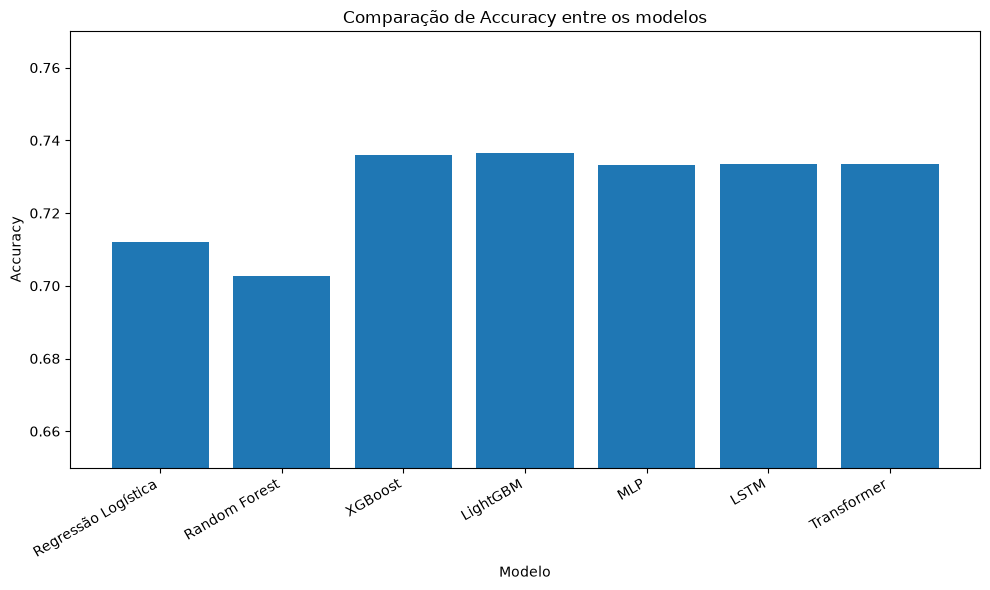

In [132]:
#Gráfico de accuracy.

plt.figure(figsize=(10, 6))

plt.bar(
    resultados["Modelo"],
    resultados["Accuracy"]
)

plt.title("Comparação de Accuracy entre os modelos")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.ylim(0.65, 0.77)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

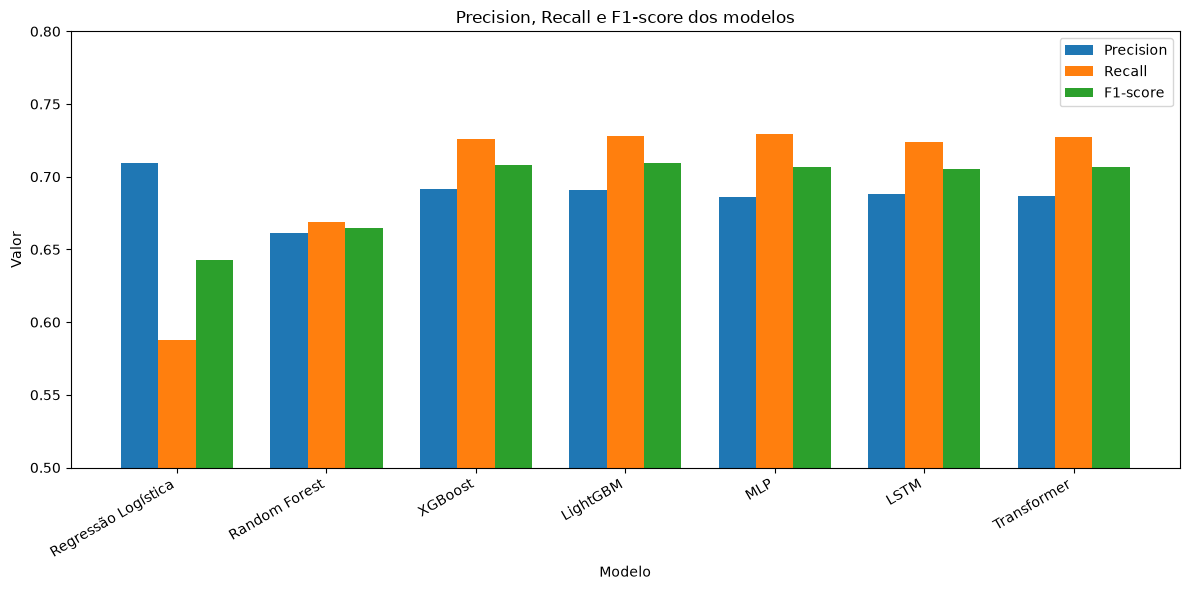

In [133]:
#Precision, Recall e F1-score

metricas = [
    "Precision",
    "Recall",
    "F1-score"
]

x = np.arange(len(resultados["Modelo"]))
largura = 0.25

plt.figure(figsize=(12, 6))

for i, metrica in enumerate(metricas):
    plt.bar(
        x + i * largura,
        resultados[metrica],
        largura,
        label=metrica
    )

plt.title("Precision, Recall e F1-score dos modelos")

plt.ylabel("Valor")
plt.xlabel("Modelo")

plt.xticks(
    x + largura,
    resultados["Modelo"],
    rotation=30,
    ha="right"
)

plt.ylim(0.5, 0.8)

plt.legend()

plt.tight_layout()
plt.show()

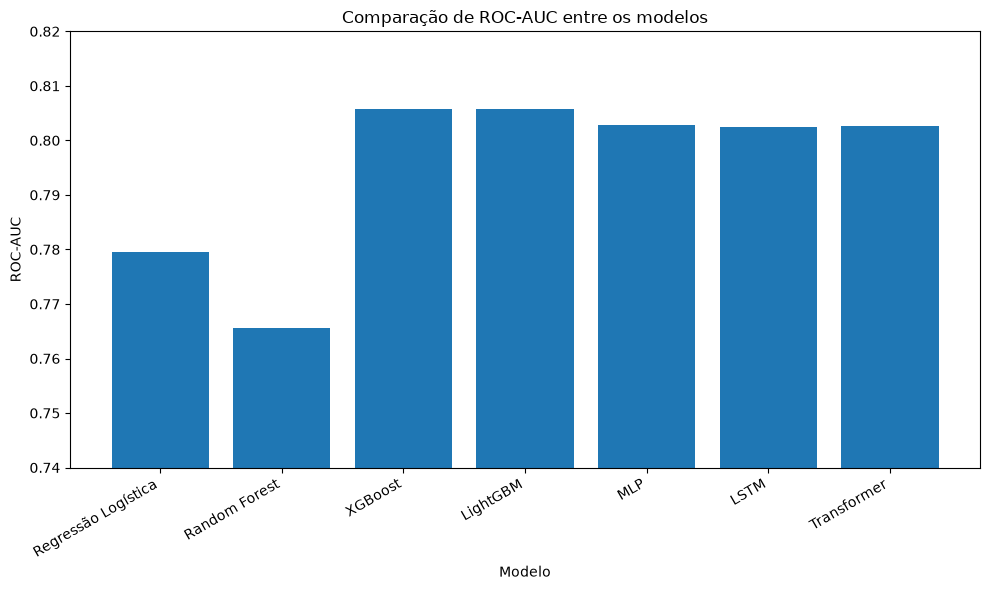

In [134]:
#ROC-AUC
plt.figure(figsize=(10, 6))

plt.bar(
    resultados["Modelo"],
    resultados["ROC-AUC"]
)

plt.title("Comparação de ROC-AUC entre os modelos")
plt.ylabel("ROC-AUC")
plt.xlabel("Modelo")
plt.ylim(0.74, 0.82)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

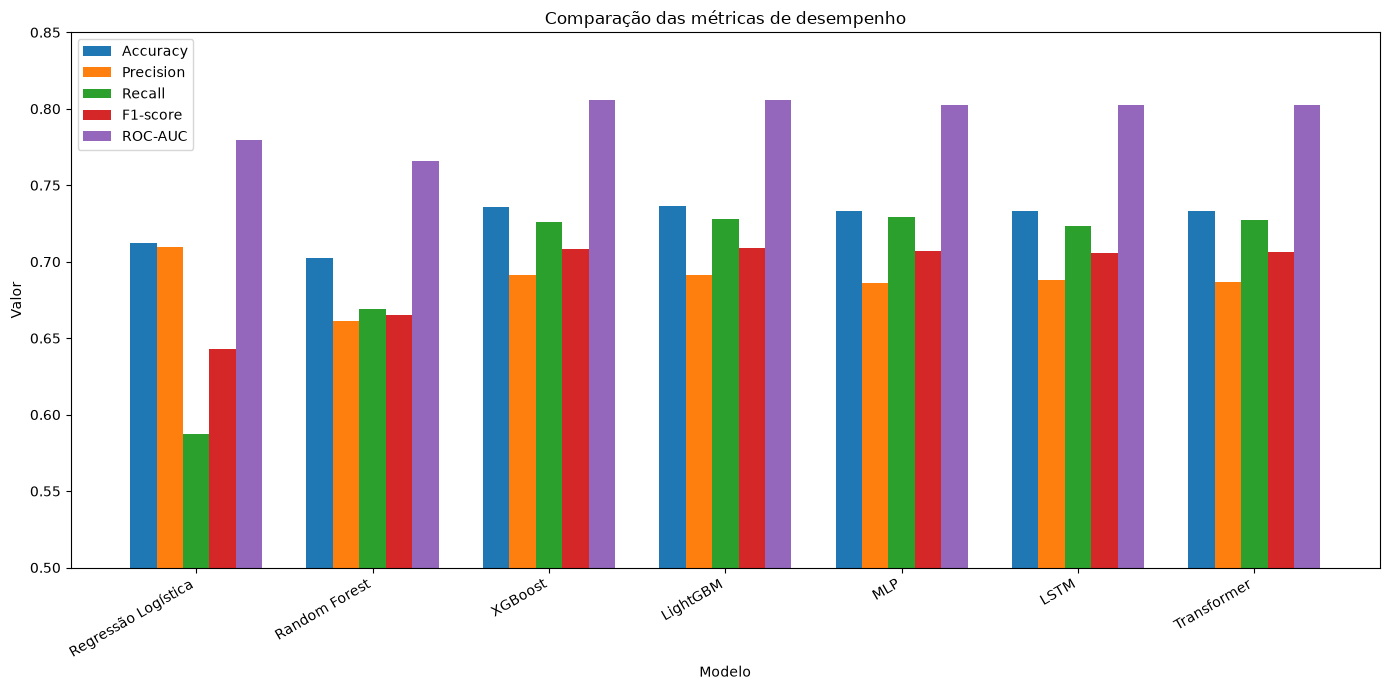

In [135]:
#Gráfico geral das cinco métricas.
metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

x = np.arange(len(resultados["Modelo"]))
largura = 0.15

plt.figure(figsize=(14, 7))

for i, metrica in enumerate(metricas):
    plt.bar(
        x + i * largura,
        resultados[metrica],
        largura,
        label=metrica
    )

plt.title("Comparação das métricas de desempenho")

plt.ylabel("Valor")
plt.xlabel("Modelo")

plt.xticks(
    x + 2 * largura,
    resultados["Modelo"],
    rotation=30,
    ha="right"
)

plt.ylim(0.5, 0.85)

plt.legend()

plt.tight_layout()
plt.show()

Matrizes de confusão.

In [136]:
matrizes = {
    "Regressão Logística": [[25244, 5904],
                            [10138, 14440]],

    "Random Forest": [[22721, 8427],
                      [8140, 16438]],

    "XGBoost": [[23182, 7966],
                [6742, 17836]],

    "LightGBM": [[23153, 7995],
                 [6685, 17893]],

    "MLP": [[22946, 8202],
            [6659, 17919]],

    "LSTM": [[23087, 8061],
             [6794, 17784]],

    "Transformer": [[22987, 8161],
                    [6696, 17882]]
}

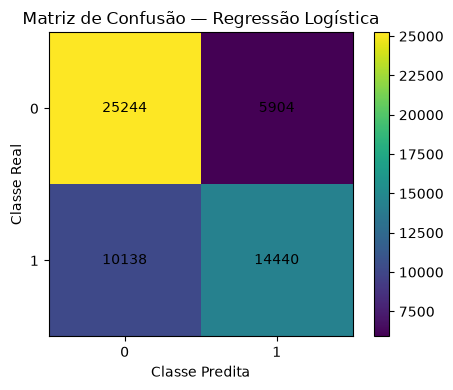

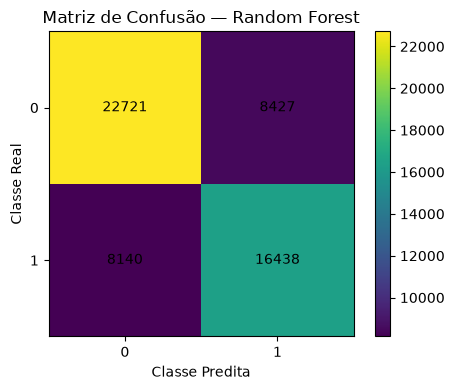

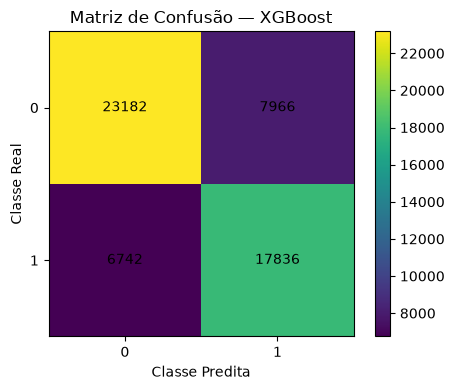

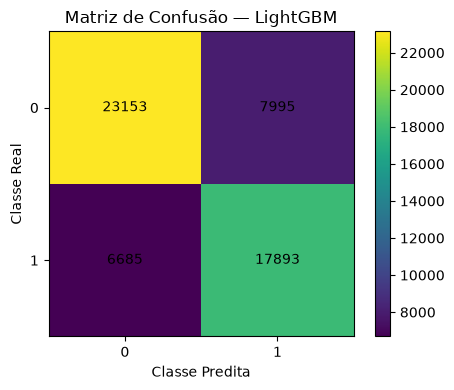

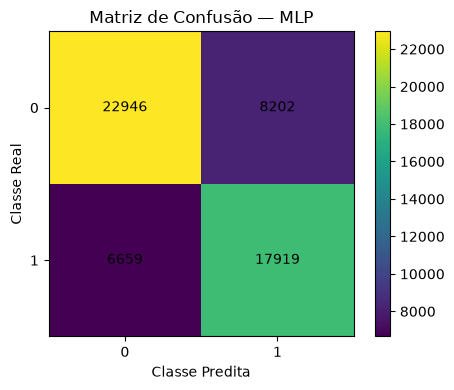

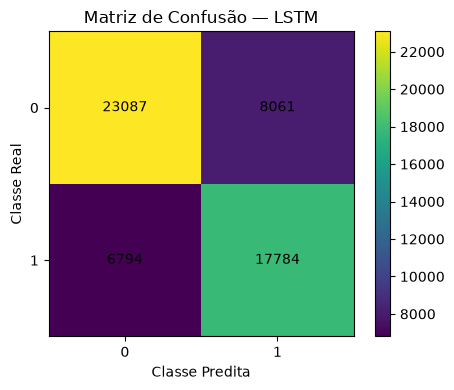

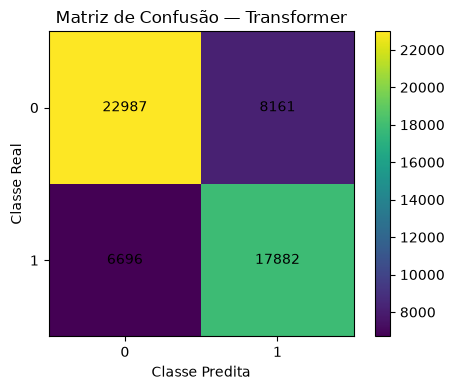

In [137]:
for modelo, matriz in matrizes.items():

    matriz = np.array(matriz)

    plt.figure(figsize=(5, 4))

    plt.imshow(matriz)

    plt.title(f"Matriz de Confusão — {modelo}")

    plt.xlabel("Classe Predita")
    plt.ylabel("Classe Real")

    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                matriz[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [138]:
#Salvando os resultados do baseline.

resultados.to_csv(
    "resultados_baseline.csv",
    index=False
)

In [139]:
print("Distribuição do TARGET:")
print(y.value_counts())

print("\nPercentual do TARGET:")
print(
    y.value_counts(normalize=True).mul(100).round(2)
)

distribuicao_target = pd.DataFrame({
    "Quantidade": y.value_counts().sort_index(),
    "Percentual": (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

distribuicao_target.index.name = "TARGET"

distribuicao_target

Distribuição do TARGET:
TARGET
0    155741
1    122887
Name: count, dtype: int64

Percentual do TARGET:
TARGET
0    55.9
1    44.1
Name: proportion, dtype: float64


,Quantidade,Percentual
TARGET,,
0,155741,55.9
1,122887,44.1


### 4º etapa: otimização de hiperparâmetros

**Modelos tradicionais**

In [140]:
#Regressão logística utilizando GridSearch
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__class_weight": [None, "balanced"]
}

In [141]:
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

In [142]:
print("Melhores parâmetros:")
print(grid_lr.best_params_)

print("Melhor ROC-AUC CV:")
print(grid_lr.best_score_)

Melhores parâmetros:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear'}
Melhor ROC-AUC CV:
0.7803676348119477


In [143]:
#Random Forest utilizando RandomizedSearch
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_rf = {
    "classifier__n_estimators": randint(100, 301),
    "classifier__max_depth": [None, 5, 10, 15, 20, 25, 30],
    "classifier__min_samples_split": randint(2, 11),
    "classifier__min_samples_leaf": randint(1, 6),
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__class_weight": [None, "balanced"]
}

cv_rf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_rf,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=False,
    refit=True
)

random_rf.fit(X_train, y_train)

print("\nMelhores parâmetros:")
print(random_rf.best_params_)

print("\nMelhor ROC-AUC CV:")
print(random_rf.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores parâmetros:
{'classifier__class_weight': None, 'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 9, 'classifier__n_estimators': 288}

Melhor ROC-AUC CV:
0.8029421318141313


In [144]:
rf_tuned = random_rf.best_estimator_

In [145]:
#XGBoost utilizando RandomizedSearch.
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_xgb = {
    "classifier__n_estimators": randint(100, 401),
    "classifier__max_depth": randint(3, 9),
    "classifier__learning_rate": uniform(0.02, 0.18),
    "classifier__subsample": uniform(0.7, 0.3),
    "classifier__colsample_bytree": uniform(0.7, 0.3),
    "classifier__min_child_weight": randint(1, 8),
    "classifier__gamma": uniform(0, 0.5)
}

cv_xgb = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_xgb,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=False,
    refit=True
)

random_xgb.fit(X_train, y_train)

print("\nMelhores parâmetros:")
print(random_xgb.best_params_)

print("\nMelhor ROC-AUC CV:")
print(random_xgb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores parâmetros:
{'classifier__colsample_bytree': np.float64(0.7299924747454009), 'classifier__gamma': np.float64(0.22962444598293358), 'classifier__learning_rate': np.float64(0.08006755000502393), 'classifier__max_depth': 5, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 357, 'classifier__subsample': np.float64(0.9165996316800473)}

Melhor ROC-AUC CV:
0.8056150933040147


In [146]:
xgb_tuned = random_xgb.best_estimator_

In [147]:
#LightBGM utilizando RandomizedSearch.
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

lgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

param_dist_lgbm = {
    "classifier__n_estimators": randint(100, 401),
    "classifier__max_depth": [-1, 3, 5, 7, 10],
    "classifier__num_leaves": randint(15, 64),
    "classifier__learning_rate": uniform(0.02, 0.18),
    "classifier__subsample": uniform(0.7, 0.3),
    "classifier__colsample_bytree": uniform(0.7, 0.3),
    "classifier__min_child_samples": randint(10, 51)
}

cv_lgbm = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_lgbm = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist_lgbm,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_lgbm,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=False,
    refit=True
)

random_lgbm.fit(X_train, y_train)

print("\nMelhores parâmetros:")
print(random_lgbm.best_params_)

print("\nMelhor ROC-AUC CV:")
print(random_lgbm.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores parâmetros:
{'classifier__colsample_bytree': np.float64(0.7546708263364187), 'classifier__learning_rate': np.float64(0.15596505385717743), 'classifier__max_depth': 3, 'classifier__min_child_samples': 13, 'classifier__n_estimators': 290, 'classifier__num_leaves': 32, 'classifier__subsample': np.float64(0.9325398470083344)}

Melhor ROC-AUC CV:
0.8055074808525543


In [148]:
lgbm_tuned = random_lgbm.best_estimator_

In [149]:
#MLP utilizando RandomizedSearch.
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

# ------------------------------------------------------------
# 1. Modelo base
# ------------------------------------------------------------

mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        random_state=42,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    ))
])

# ------------------------------------------------------------
# 2. Espaço de busca
# ------------------------------------------------------------

param_dist_mlp = {
    "classifier__hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64)
    ],
    
    "classifier__activation": [
        "relu",
        "tanh"
    ],
    
    "classifier__alpha": loguniform(1e-5, 1e-2),
    
    "classifier__learning_rate_init": loguniform(1e-4, 1e-2),
    
    "classifier__batch_size": [
        128,
        256,
        512
    ]
}

# ------------------------------------------------------------
# 3. Validação cruzada estratificada
# ------------------------------------------------------------

cv_mlp = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 4. Randomized Search
# ------------------------------------------------------------

random_mlp = RandomizedSearchCV(
    estimator=mlp_model,
    param_distributions=param_dist_mlp,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_mlp,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=False,
    refit=True
)

# ------------------------------------------------------------
# 5. Execução do tuning
# ------------------------------------------------------------

random_mlp.fit(X_train, y_train)

# ------------------------------------------------------------
# 6. Resultados
# ------------------------------------------------------------

print("\nMelhores parâmetros:")
print(random_mlp.best_params_)

print("\nMelhor ROC-AUC CV:")
print(random_mlp.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores parâmetros:
{'classifier__activation': 'tanh', 'classifier__alpha': np.float64(0.0005987474910461401), 'classifier__batch_size': 512, 'classifier__hidden_layer_sizes': (128, 64), 'classifier__learning_rate_init': np.float64(0.0016409286730647919)}

Melhor ROC-AUC CV:
0.8041232753196763


In [150]:
mlp_tuned = random_mlp.best_estimator_

LSTM e Transformer utilizarão validação estratificada.

In [151]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tensorflow.keras.layers import (
    Input, Dense, Embedding, Reshape, Concatenate,
    Lambda, LSTM, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

indices = np.arange(len(y_train_nn))

idx_train_lstm, idx_val_lstm = train_test_split(
    indices,
    test_size=0.10,
    stratify=y_train_nn,
    random_state=42
)

# Dados numéricos
X_train_num_lstm = X_train_num[idx_train_lstm]
X_val_num_lstm = X_train_num[idx_val_lstm]

# Dados categóricos
X_train_cat_lstm = X_train_cat[idx_train_lstm]
X_val_cat_lstm = X_train_cat[idx_val_lstm]

# Target
y_train_lstm = y_train_nn[idx_train_lstm]
y_val_lstm = y_train_nn[idx_val_lstm]

def build_lstm_model(
    lstm_units=64,
    dense_units=32,
    dropout_rate=0.3,
    learning_rate=0.001
):

    K.clear_session()

    EMBED_DIM = 16

    # Entrada numérica
    input_num_tune = Input(
        shape=(3,),
        name="numericas"
    )

    # Entradas categóricas
    inputs_cat_tune = []

    for col in features_categoricas:
        inputs_cat_tune.append(
            Input(
                shape=(1,),
                dtype="int32",
                name=col
            )
        )

    num_tokens_tune = []

    for i in range(3):

        x = Lambda(
            lambda z, i=i: z[:, i:i+1]
        )(input_num_tune)

        x = Dense(
            EMBED_DIM
        )(x)

        x = Reshape(
            (1, EMBED_DIM)
        )(x)

        num_tokens_tune.append(x)

    cat_tokens_tune = []

    for i, col in enumerate(features_categoricas):

        vocab_size = categorical_cardinalities[col]

        embedding = Embedding(
            input_dim=vocab_size,
            output_dim=EMBED_DIM
        )(inputs_cat_tune[i])

        cat_tokens_tune.append(embedding)


    tokens_tune = num_tokens_tune + cat_tokens_tune

    sequence_input_tune = Concatenate(
        axis=1
    )(tokens_tune)

    x = LSTM(
        lstm_units
    )(sequence_input_tune)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        dense_units,
        activation="relu"
    )(x)

    x = Dropout(
        dropout_rate
    )(x)

    output_tune = Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs=[input_num_tune] + inputs_cat_tune,
        outputs=output_tune
    )

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    return model

lstm_configs = [
    {
        "lstm_units": 32,
        "dense_units": 16,
        "dropout_rate": 0.2,
        "learning_rate": 0.001
    },
    {
        "lstm_units": 64,
        "dense_units": 32,
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },
    {
        "lstm_units": 128,
        "dense_units": 32,
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },
    {
        "lstm_units": 64,
        "dense_units": 32,
        "dropout_rate": 0.4,
        "learning_rate": 0.0005
    },
    {
        "lstm_units": 128,
        "dense_units": 64,
        "dropout_rate": 0.4,
        "learning_rate": 0.0005
    }
]

train_data_tune = [
    X_train_num_lstm
] + [
    X_train_cat_lstm[:, i:i+1]
    for i in range(len(features_categoricas))
]

val_data_tune = [
    X_val_num_lstm
] + [
    X_val_cat_lstm[:, i:i+1]
    for i in range(len(features_categoricas))
]

lstm_results = []

best_lstm_model = None
best_lstm_auc = -np.inf
best_lstm_params = None

for i, params in enumerate(lstm_configs, start=1):

    print("\n" + "=" * 60)
    print(f"Configuração {i}/{len(lstm_configs)}")
    print(params)
    print("=" * 60)

    model = build_lstm_model(**params)

    early_stopping = EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        train_data_tune,
        y_train_lstm,
        validation_data=(val_data_tune, y_val_lstm),
        epochs=20,
        batch_size=512,
        callbacks=[early_stopping],
        verbose=1
    )

    # Melhor AUROC da validação durante o treinamento
    val_auc = max(history.history["val_auc"])

    lstm_results.append({
        "config": params,
        "val_auc": val_auc
    })

    print(f"\nAUROC de validação: {val_auc:.6f}")

    # Guarda o melhor modelo
    if val_auc > best_lstm_auc:

        best_lstm_auc = val_auc
        best_lstm_params = params.copy()

        # Salva os pesos do melhor modelo
        best_lstm_weights = model.get_weights()

    del model
    K.clear_session()

print("\n" + "=" * 60)
print("RESULTADO FINAL DO TUNING — LSTM")
print("=" * 60)

print("\nMelhores parâmetros:")
print(best_lstm_params)

print("\nMelhor ROC-AUC de validação:")
print(best_lstm_auc)


Configuração 1/5
{'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001}
Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - auc: 0.7783 - loss: 0.5640 - val_auc: 0.7969 - val_loss: 0.5416
Epoch 2/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.7954 - loss: 0.5455 - val_auc: 0.7977 - val_loss: 0.5421
Epoch 3/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.7963 - loss: 0.5442 - val_auc: 0.7980 - val_loss: 0.5421
Epoch 4/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - auc: 0.7967 - loss: 0.5436 - val_auc: 0.7984 - val_loss: 0.5409
Epoch 5/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.7973 - loss: 0.5426 - val_auc: 0.7983 - val_loss: 0.5418
Epoch 6/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.7976 - loss: 0.5422 - val_auc: 0.7987 - val_loss: 0.5397
Epoch 7/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.7978 - loss: 0.5421 - val_auc: 0.7985 - val_loss: 0.5403
Epoch 8/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.7979 

In [152]:
lstm_tuned = build_lstm_model(**best_lstm_params)

lstm_tuned.set_weights(best_lstm_weights)

print("\nMelhor LSTM reconstruído com sucesso.")

print("Melhores parâmetros do LSTM:")
print(best_lstm_params)


Melhor LSTM reconstruído com sucesso.
Melhores parâmetros do LSTM:
{'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001}


In [153]:
#Transformer.
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    Reshape,
    Concatenate,
    Lambda,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D,
    Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K


indices = np.arange(len(y_train_nn))

idx_train_trans, idx_val_trans = train_test_split(
    indices,
    test_size=0.10,
    stratify=y_train_nn,
    random_state=42
)

# Dados numéricos
X_train_num_trans = X_train_num[idx_train_trans]
X_val_num_trans = X_train_num[idx_val_trans]

# Dados categóricos
X_train_cat_trans = X_train_cat[idx_train_trans]
X_val_cat_trans = X_train_cat[idx_val_trans]

# Target
y_train_trans = y_train_nn[idx_train_trans]
y_val_trans = y_train_nn[idx_val_trans]


def transformer_block_tune(
    x,
    embed_dim=16,
    num_heads=4,
    ff_dim=32,
    dropout=0.3
):

    # Multi-Head Self-Attention
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim,
        dropout=dropout
    )(x, x)

    attention_output = Dropout(dropout)(
        attention_output
    )

    # Conexão residual + normalização
    x1 = LayerNormalization(
        epsilon=1e-6
    )(x + attention_output)

    # Feed Forward
    ff_output = Dense(
        ff_dim,
        activation="relu"
    )(x1)

    ff_output = Dense(
        embed_dim
    )(ff_output)

    ff_output = Dropout(dropout)(
        ff_output
    )

    # Segunda conexão residual + normalização
    return LayerNormalization(
        epsilon=1e-6
    )(x1 + ff_output)


def build_transformer_model(
    num_heads=4,
    ff_dim=32,
    dense_units=32,
    dropout_rate=0.3,
    learning_rate=0.001
):

    K.clear_session()

    EMBED_DIM = 16
    SEQUENCE_LENGTH = 12


    input_num_tune = Input(
        shape=(3,),
        name="numericas"
    )

    inputs_cat_tune = []

    for col in features_categoricas:

        inputs_cat_tune.append(
            Input(
                shape=(1,),
                dtype="int32",
                name=col
            )
        )


    num_tokens_tune = []

    for i in range(3):

        x = Lambda(
            lambda z, i=i: z[:, i:i+1]
        )(input_num_tune)

        x = Dense(
            EMBED_DIM
        )(x)

        x = Reshape(
            (1, EMBED_DIM)
        )(x)

        num_tokens_tune.append(x)


    cat_tokens_tune = []

    for i, col in enumerate(features_categoricas):

        vocab_size = categorical_cardinalities[col]

        embedding = Embedding(
            input_dim=vocab_size,
            output_dim=EMBED_DIM
        )(inputs_cat_tune[i])

        cat_tokens_tune.append(
            embedding
        )


    tokens_tune = (
        num_tokens_tune +
        cat_tokens_tune
    )

    sequence_input_tune = Concatenate(
        axis=1
    )(tokens_tune)


    positions = tf.range(
        start=0,
        limit=SEQUENCE_LENGTH,
        delta=1
    )

    position_embedding = Embedding(
        input_dim=SEQUENCE_LENGTH,
        output_dim=EMBED_DIM
    )(positions)

    x = sequence_input_tune + position_embedding


    x = transformer_block_tune(
        x,
        embed_dim=EMBED_DIM,
        num_heads=num_heads,
        ff_dim=ff_dim,
        dropout=dropout_rate
    )


    x = GlobalAveragePooling1D()(x)

    x = Dense(
        dense_units,
        activation="relu"
    )(x)

    x = Dropout(
        dropout_rate
    )(x)

    output = Dense(
        1,
        activation="sigmoid",
        name="output"
    )(x)

    model = Model(
        inputs=[input_num_tune] + inputs_cat_tune,
        outputs=output,
        name="Transformer_SINAN_Tuned"
    )

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    return model


transformer_configs = [

    {
        "num_heads": 2,
        "ff_dim": 32,
        "dense_units": 32,
        "dropout_rate": 0.2,
        "learning_rate": 0.001
    },

    {
        "num_heads": 4,
        "ff_dim": 32,
        "dense_units": 32,
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },

    {
        "num_heads": 4,
        "ff_dim": 64,
        "dense_units": 32,
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },

    {
        "num_heads": 4,
        "ff_dim": 64,
        "dense_units": 64,
        "dropout_rate": 0.4,
        "learning_rate": 0.0005
    },

    {
        "num_heads": 8,
        "ff_dim": 64,
        "dense_units": 64,
        "dropout_rate": 0.4,
        "learning_rate": 0.0005
    }
]


train_data_trans = [
    X_train_num_trans
] + [
    X_train_cat_trans[:, i:i+1]
    for i in range(len(features_categoricas))
]

val_data_trans = [
    X_val_num_trans
] + [
    X_val_cat_trans[:, i:i+1]
    for i in range(len(features_categoricas))
]


transformer_results = []

best_transformer_model = None
best_transformer_auc = -np.inf
best_transformer_params = None
best_transformer_weights = None


for i, params in enumerate(
    transformer_configs,
    start=1
):

    print("\n" + "=" * 60)
    print(
        f"Configuração {i}/{len(transformer_configs)}"
    )
    print(params)
    print("=" * 60)

    model = build_transformer_model(
        **params
    )

    early_stopping = EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        train_data_trans,
        y_train_trans,
        validation_data=(
            val_data_trans,
            y_val_trans
        ),
        epochs=20,
        batch_size=512,
        callbacks=[early_stopping],
        verbose=1
    )

    # Melhor AUROC da validação
    val_auc = max(
        history.history["val_auc"]
    )

    transformer_results.append({
        "config": params,
        "val_auc": val_auc
    })

    print(
        f"\nAUROC de validação: "
        f"{val_auc:.6f}"
    )

    # Guarda o melhor modelo
    if val_auc > best_transformer_auc:

        best_transformer_auc = val_auc

        best_transformer_params = (
            params.copy()
        )

        best_transformer_weights = (
            model.get_weights()
        )

    del model
    K.clear_session()


print("\n" + "=" * 60)
print("RESULTADO FINAL DO TUNING — TRANSFORMER")
print("=" * 60)

print("\nMelhores parâmetros:")
print(best_transformer_params)

print("\nMelhor ROC-AUC de validação:")
print(best_transformer_auc)


Configuração 1/5
{'num_heads': 2, 'ff_dim': 32, 'dense_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001}
Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - auc: 0.7793 - loss: 0.5606 - val_auc: 0.7981 - val_loss: 0.5415
Epoch 2/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7974 - loss: 0.5421 - val_auc: 0.7985 - val_loss: 0.5431
Epoch 3/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7984 - loss: 0.5407 - val_auc: 0.7987 - val_loss: 0.5399
Epoch 4/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7990 - loss: 0.5400 - val_auc: 0.7991 - val_loss: 0.5405
Epoch 5/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - auc: 0.7990 - loss: 0.5400 - val_auc: 0.7986 - val_loss: 0.5407
Epoch 6/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7993 - loss: 0.5395 - val_auc: 0.7990 - val_loss: 0.5417
Epoch 7/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7997 - loss: 0.5394 - val_auc: 0.7990 - val_loss: 0.5404

AUROC de validação: 0.799068

Configuração 2/5
{'num

In [154]:
transformer_tuned = build_transformer_model(
    **best_transformer_params
)

transformer_tuned.set_weights(
    best_transformer_weights
)

print(
    "\nMelhor Transformer reconstruído com sucesso."
)


Melhor Transformer reconstruído com sucesso.



Avaliando: Logistic Regression
Accuracy : 0.714675
Precision: 0.673685
Recall   : 0.684759
F1-Score : 0.679177
ROC-AUC  : 0.780356
AUPRC    : 0.712360

Matriz de confusão:
[[22996  8152]
 [ 7748 16830]]

Avaliando: Random Forest
Accuracy : 0.734648
Precision: 0.681766
Recall   : 0.747091
F1-Score : 0.712935
ROC-AUC  : 0.803060
AUPRC    : 0.738655

Matriz de confusão:
[[22577  8571]
 [ 6216 18362]]

Avaliando: XGBoost
Accuracy : 0.735850
Precision: 0.691299
Recall   : 0.724713
F1-Score : 0.707612
ROC-AUC  : 0.805539
AUPRC    : 0.744659

Matriz de confusão:
[[23194  7954]
 [ 6766 17812]]

Avaliando: LightGBM
Accuracy : 0.736425
Precision: 0.692039
Recall   : 0.725039
F1-Score : 0.708155
ROC-AUC  : 0.805323
AUPRC    : 0.744297

Matriz de confusão:
[[23218  7930]
 [ 6758 17820]]

Avaliando: MLP
Accuracy : 0.734917
Precision: 0.696686
Recall   : 0.706608
F1-Score : 0.701612
ROC-AUC  : 0.804353
AUPRC    : 0.741357

Matriz de confusão:
[[23587  7561]
 [ 7211 17367]]

Avaliando: LSTM
Accuracy

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AUPRC
0,XGBoost,0.7359,0.6913,0.7247,0.7076,0.8055,0.7447
1,LightGBM,0.7364,0.6920,0.7250,0.7082,0.8053,0.7443
2,MLP,0.7349,0.6967,0.7066,0.7016,0.8044,0.7414
3,Transformer,0.7333,0.6957,0.7028,0.6992,0.8034,0.7411
4,LSTM,0.7345,0.6849,0.7372,0.7101,0.8034,0.7411
5,Random Forest,0.7346,0.6818,0.7471,0.7129,0.8031,0.7387
6,Logistic Regression,0.7147,0.6737,0.6848,0.6792,0.7804,0.7124




MODELO COM MAIOR ROC-AUC NO CONJUNTO DE TESTE
Modelo: XGBoost
ROC-AUC: 0.805539


<Figure size 1400x700 with 0 Axes>

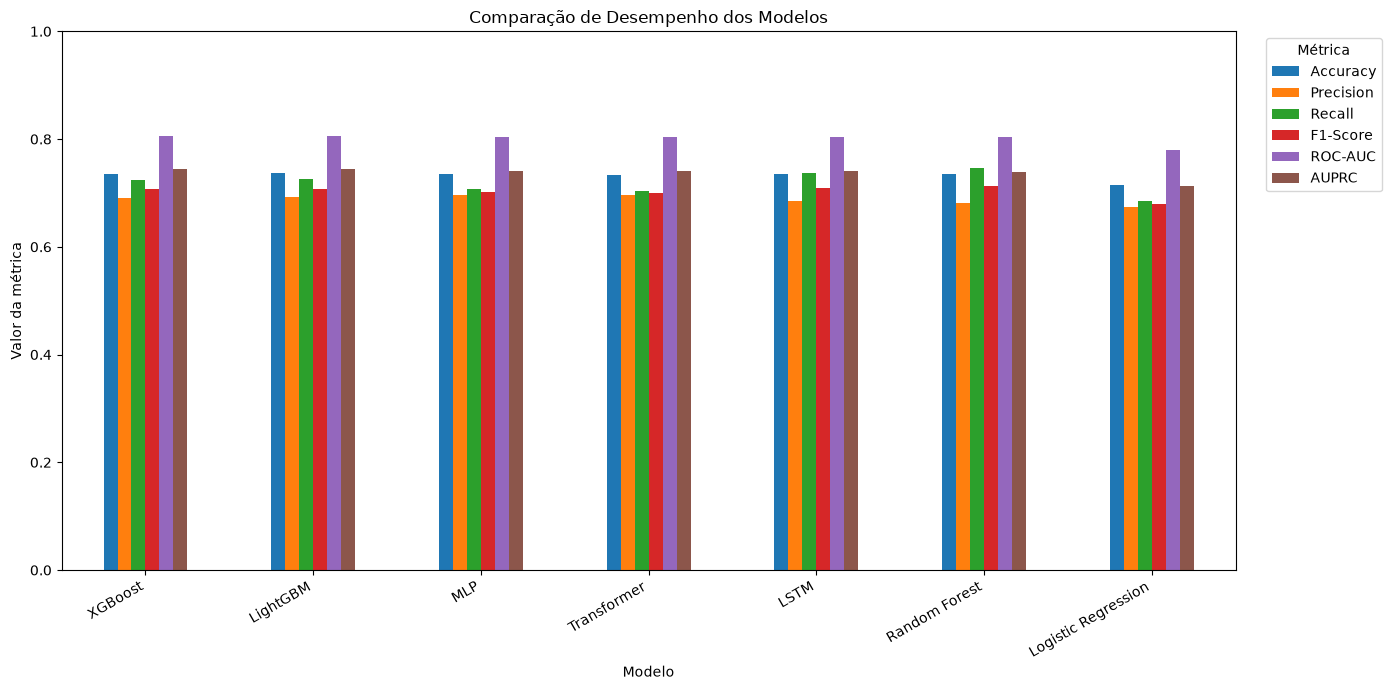

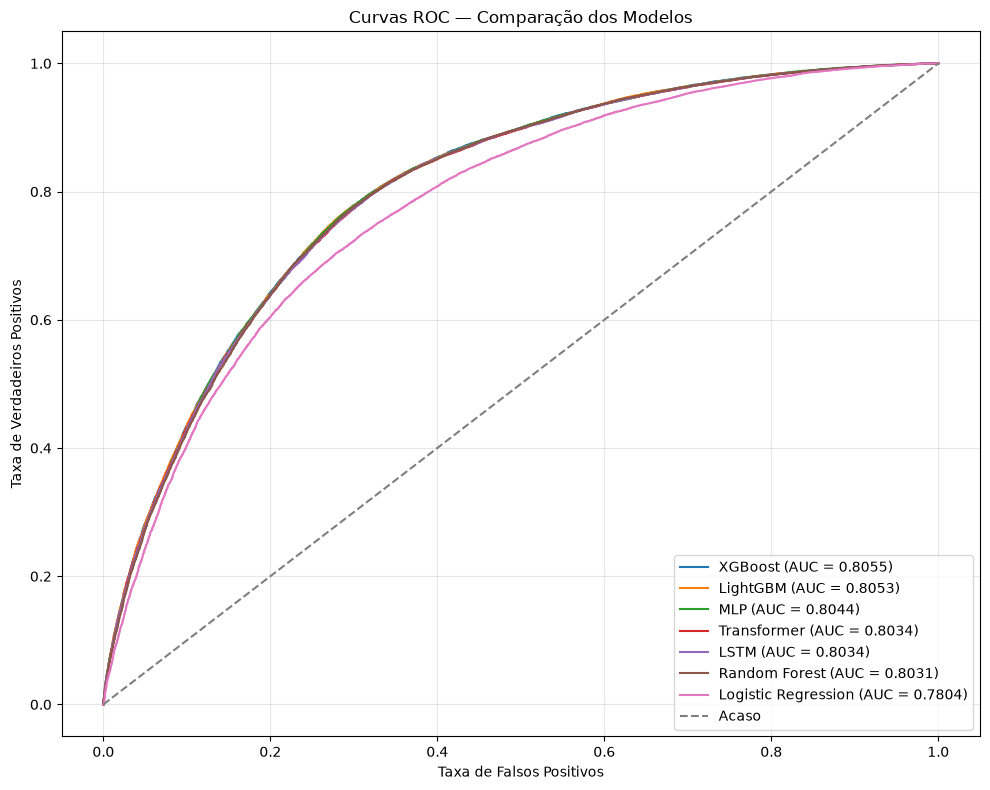

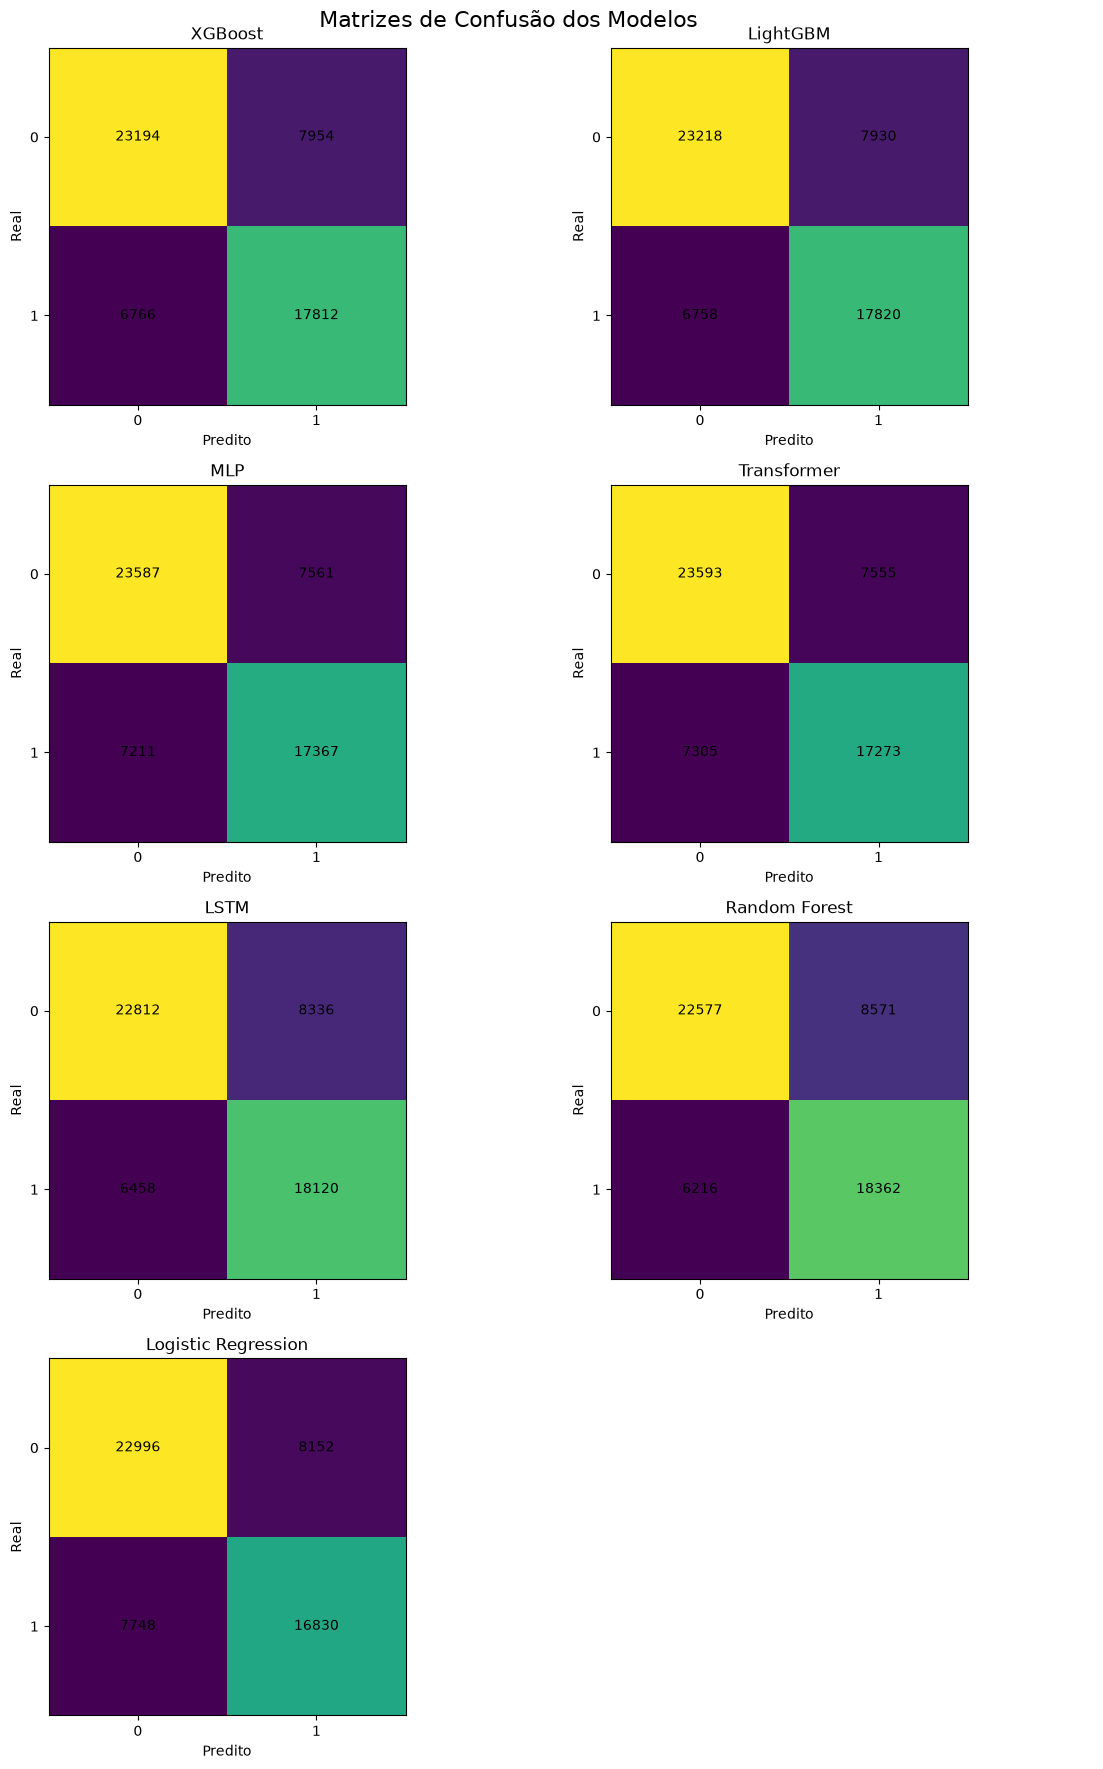


Tabela salva como: resultados_finais_modelos_tunados.csv


In [155]:
# ============================================================
# AVALIAÇÃO FINAL — 7 MODELOS OTIMIZADOS
# ============================================================
#
# Conjunto utilizado: X_test / y_test
# Métrica de otimização dos tunings: ROC-AUC
#
# Modelos:
# 1. Logistic Regression
# 2. Random Forest
# 3. XGBoost
# 4. LightGBM
# 5. MLP
# 6. LSTM
# 7. Transformer
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve
)


# ============================================================
# 1. DICIONÁRIO DOS MODELOS TUNADOS
# ============================================================

modelos_tunados = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Random Forest": random_rf.best_estimator_,
    "XGBoost": random_xgb.best_estimator_,
    "LightGBM": random_lgbm.best_estimator_,
    "MLP": random_mlp.best_estimator_,
    "LSTM": lstm_tuned,
    "Transformer": transformer_tuned
}


# ============================================================
# 2. PREPARAÇÃO DOS DADOS PARA AS REDES NEURAIS
# ============================================================

test_data_nn = [
    X_test_num
] + [
    X_test_cat[:, i:i+1]
    for i in range(len(features_categoricas))
]


# ============================================================
# 3. AVALIAÇÃO DOS MODELOS
# ============================================================

resultados = []

probabilidades = {}

predicoes = {}

matrizes_confusao = {}


for nome, modelo in modelos_tunados.items():

    print("\n" + "=" * 70)
    print(f"Avaliando: {nome}")
    print("=" * 70)

    # --------------------------------------------------------
    # Modelos tradicionais
    # --------------------------------------------------------

    if nome in [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "MLP"
    ]:

        y_prob = modelo.predict_proba(
            X_test
        )[:, 1]

    # --------------------------------------------------------
    # LSTM e Transformer
    # --------------------------------------------------------

    else:

        y_prob = modelo.predict(
            test_data_nn,
            batch_size=512,
            verbose=0
        ).ravel()

    # --------------------------------------------------------
    # Classificação utilizando threshold = 0.5
    # --------------------------------------------------------

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    auprc = average_precision_score(
        y_test,
        y_prob
    )

    # --------------------------------------------------------
    # Matriz de confusão
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    # --------------------------------------------------------
    # Armazenamento
    # --------------------------------------------------------

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "AUPRC": auprc
    })

    probabilidades[nome] = y_prob
    predicoes[nome] = y_pred
    matrizes_confusao[nome] = cm

    # --------------------------------------------------------
    # Exibição individual
    # --------------------------------------------------------

    print(f"Accuracy : {accuracy:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall   : {recall:.6f}")
    print(f"F1-Score : {f1:.6f}")
    print(f"ROC-AUC  : {roc_auc:.6f}")
    print(f"AUPRC    : {auprc:.6f}")

    print("\nMatriz de confusão:")
    print(cm)


# ============================================================
# 4. DATAFRAME FINAL
# ============================================================

resultados_finais = pd.DataFrame(
    resultados
)

# Ordenar pela ROC-AUC
resultados_finais = resultados_finais.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 5. EXIBIR RESULTADOS
# ============================================================

print("\n")
print("=" * 90)
print("COMPARAÇÃO FINAL DOS 7 MODELOS")
print("=" * 90)

display(
    resultados_finais.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "AUPRC": "{:.4f}"
    })
)


# ============================================================
# 6. IDENTIFICAR O MODELO COM MAIOR ROC-AUC
# ============================================================

melhor_modelo = resultados_finais.iloc[0]

print("\n")
print("=" * 70)
print("MODELO COM MAIOR ROC-AUC NO CONJUNTO DE TESTE")
print("=" * 70)

print(
    f"Modelo: {melhor_modelo['Modelo']}"
)

print(
    f"ROC-AUC: {melhor_modelo['ROC-AUC']:.6f}"
)


# ============================================================
# 7. GRÁFICO — COMPARAÇÃO DAS MÉTRICAS
# ============================================================

metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "AUPRC"
]

df_plot = resultados_finais.set_index(
    "Modelo"
)[metricas]


plt.figure(figsize=(14, 7))

df_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparação de Desempenho dos Modelos")

plt.ylabel("Valor da métrica")

plt.xlabel("Modelo")

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. CURVAS ROC DOS 7 MODELOS
# ============================================================

plt.figure(figsize=(10, 8))

for nome in resultados_finais["Modelo"]:

    y_prob = probabilidades[nome]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nome} (AUC = {auc:.4f})"
    )


# Linha de referência do acaso
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Acaso"
)

plt.xlabel("Taxa de Falsos Positivos")

plt.ylabel("Taxa de Verdadeiros Positivos")

plt.title("Curvas ROC — Comparação dos Modelos")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 9. MATRIZES DE CONFUSÃO
# ============================================================

fig, axes = plt.subplots(
    4,
    2,
    figsize=(12, 18)
)

axes = axes.flatten()

for i, nome in enumerate(
    resultados_finais["Modelo"]
):

    cm = matrizes_confusao[nome]

    ax = axes[i]

    im = ax.imshow(cm)

    ax.set_title(nome)

    ax.set_xlabel("Predito")

    ax.set_ylabel("Real")

    ax.set_xticks([0, 1])

    ax.set_yticks([0, 1])

    ax.set_xticklabels(["0", "1"])

    ax.set_yticklabels(["0", "1"])

    # Valores dentro da matriz
    for linha in range(2):

        for coluna in range(2):

            ax.text(
                coluna,
                linha,
                cm[linha, coluna],
                ha="center",
                va="center"
            )


# Remove o oitavo espaço vazio
axes[-1].axis("off")

plt.suptitle(
    "Matrizes de Confusão dos Modelos",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. EXPORTAR TABELA DE RESULTADOS
# ============================================================

resultados_finais.to_csv(
    "resultados_finais_modelos_tunados.csv",
    index=False
)

print(
    "\nTabela salva como: "
    "resultados_finais_modelos_tunados.csv"
)

**Adicionando shap e beeswarm**

In [156]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\WZETTA\OneDrive\Documentos\python\projetoSinan\dadosSinan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [157]:
xgb_final = random_xgb.best_estimator_
preprocessor_xgb = xgb_final.named_steps["preprocessor"]
model_xgb = xgb_final.named_steps["classifier"]

In [158]:
X_test_transformed = preprocessor_xgb.transform(X_test)

In [159]:
feature_names = preprocessor_xgb.get_feature_names_out()

print("Número de features após transformação:", len(feature_names))

Número de features após transformação: 45


In [160]:
#Utilizando uma amostra aleatória de 5000 registros para o SHAP
np.random.seed(42)

n_amostra = min(5000, X_test_transformed.shape[0])

indices_shap = np.random.choice(
    X_test_transformed.shape[0],
    size=n_amostra,
    replace=False
)

X_shap = X_test_transformed[indices_shap]

print("Amostra utilizada no SHAP:", X_shap.shape)

Amostra utilizada no SHAP: (5000, 45)


In [161]:
explainer = shap.TreeExplainer(model_xgb)

shap_values = explainer.shap_values(X_shap)

C:\Users\WZETTA\AppData\Local\Temp\ipykernel_19652\2618535401.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


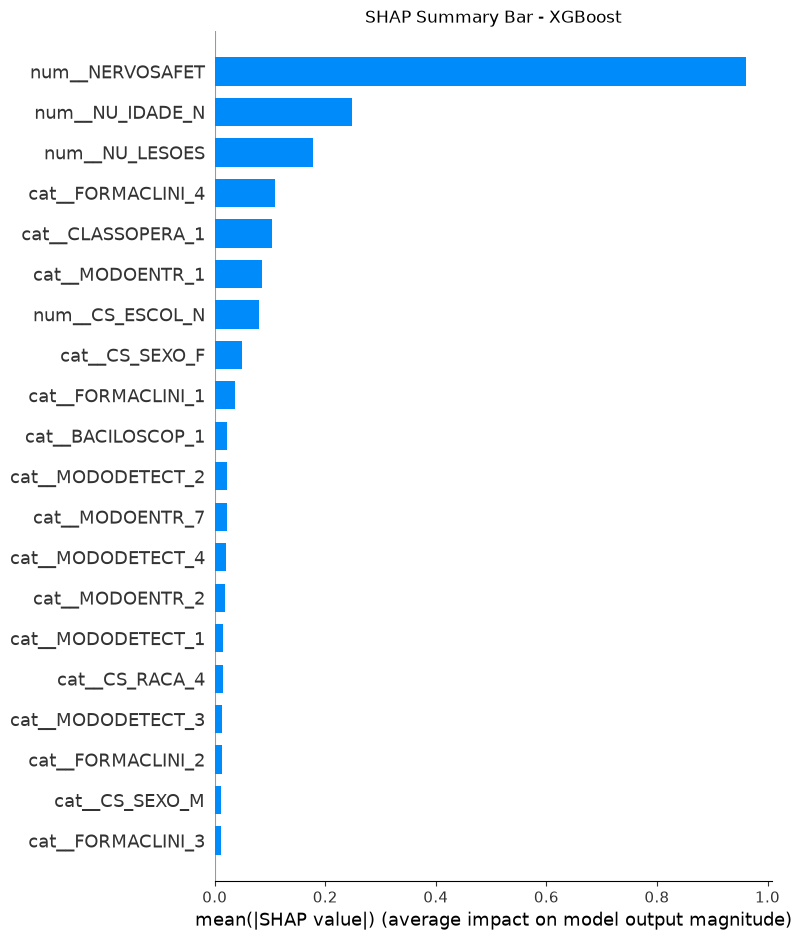

In [ ]:
#Summary bar de todas as features incluindo One Hot encoding
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Summary Bar - XGBoost")
plt.tight_layout()
plt.show()

In [165]:
variaveis_originais = [
    "NU_IDADE_N",
    "NU_LESOES",
    "NERVOSAFET",
    "CS_ESCOL_N",
    "CS_SEXO",
    "CS_RACA",
    "CLASSOPERA",
    "FORMACLINI",
    "ID_OCUPA_N",
    "MODOENTR",
    "MODODETECT",
    "BACILOSCOP"
]

def identificar_variavel_original(nome):
    
    nome = nome.replace("num__", "")
    nome = nome.replace("cat__", "")
    
    for variavel in variaveis_originais:
        if nome == variavel or nome.startswith(variavel + "_"):
            return variavel
    
    return nome

In [166]:
grupos_shap = [
    identificar_variavel_original(nome)
    for nome in feature_names
]

print(pd.Series(grupos_shap).value_counts())

ID_OCUPA_N    10
MODOENTR       8
MODODETECT     6
FORMACLINI     6
CS_RACA        5
CS_SEXO        2
CLASSOPERA     2
BACILOSCOP     2
CS_ESCOL_N     1
NERVOSAFET     1
NU_LESOES      1
NU_IDADE_N     1
Name: count, dtype: int64


In [167]:
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)

shap_df_agrupado = pd.DataFrame(index=shap_df.index)

for variavel in variaveis_originais:
    
    colunas = [
        feature_names[i]
        for i, grupo in enumerate(grupos_shap)
        if grupo == variavel
    ]
    
    shap_df_agrupado[variavel] = shap_df[colunas].sum(axis=1)

In [168]:
print(shap_df_agrupado.shape)
print(shap_df_agrupado.columns.tolist())

(5000, 12)
['NU_IDADE_N', 'NU_LESOES', 'NERVOSAFET', 'CS_ESCOL_N', 'CS_SEXO', 'CS_RACA', 'CLASSOPERA', 'FORMACLINI', 'ID_OCUPA_N', 'MODOENTR', 'MODODETECT', 'BACILOSCOP']


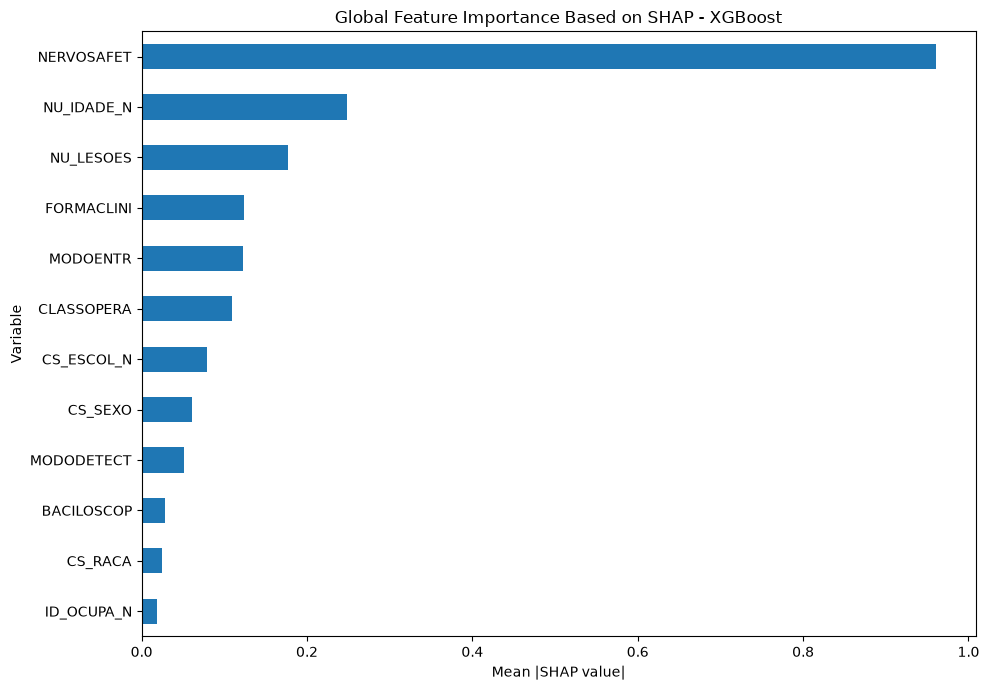

In [ ]:
#Summary bar com as features originais
importancia_shap = (
    shap_df_agrupado.abs()
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

importancia_shap.plot(kind="barh")

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Variable")
plt.title("Global Feature Importance Based on SHAP - XGBoost")

plt.tight_layout()
plt.show()

In [170]:
#Beeswarm
X_shap_original = X_test.iloc[indices_shap][variaveis_originais].copy()

C:\Users\WZETTA\AppData\Local\Temp\ipykernel_19652\2346576428.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


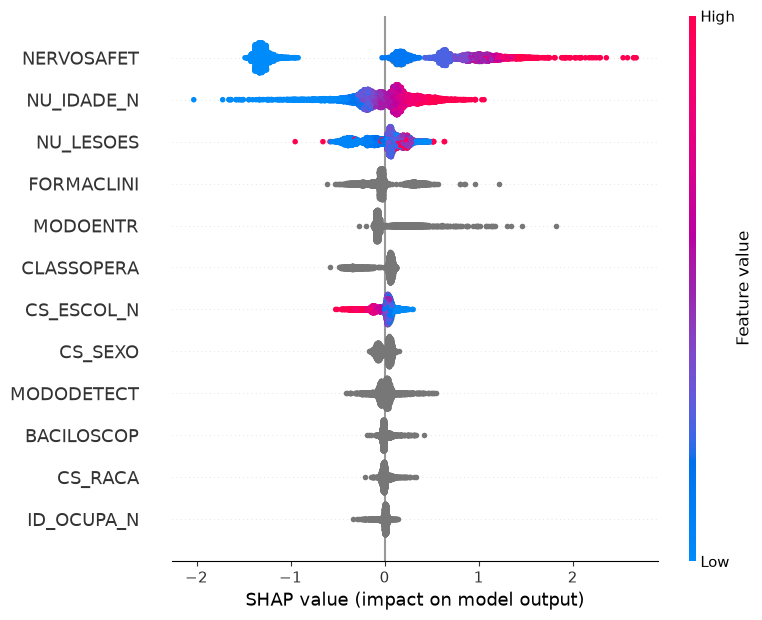

In [171]:
shap.summary_plot(
    shap_df_agrupado.values,
    X_shap_original,
    feature_names=variaveis_originais,
    max_display=12
)